## Notebook Manifest — D2C Weekly Growth & Profit Pipeline

| Phase | File | Status |
|-------|------|--------|
| 0 | config/config.py | ⬜ |
| 1 | src/data/ingest.py | ⬜ |
| 2 | src/data/clean.py | ⬜ |
| 3 | src/features/engineer.py | ⬜ |
| 4 | src/analytics/eda.py | ⬜ |
| 5 | src/models/classifier.py | ⬜ |
| 6 | src/models/segmentation.py | ⬜ |
| 7 | src/models/predictor.py | ⬜ |
| 8 | src/analytics/business_logic.py | ⬜ |
| 9 | src/analytics/insights.py | ⬜ |
| 10 | src/reporting/export.py | ⬜ |
| 11 | main.py | ⬜ |
| 12 | report.py | ⬜ |
| 13 | app.py | ⬜ |
| 14 | parse_notebook.py | ⬜ |

Run top to bottom. Every module is written once with %%writefile, then imported and validated in the next cell.


In [1]:
# SETUP: install packages, move to project root, create folders
%pip install -q pandas numpy scikit-learn matplotlib openpyxl joblib
# optional (dashboard / interactive HTML / BigQuery):  %pip install -q gradio plotly google-cloud-bigquery
import os, sys, warnings
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebook':      # notebook lives in notebook/, project root is one level up
    os.chdir('..')
for d in ['config', 'data/raw', 'data/processed', 'models', 'reports', 'notebook', 'src/data', 'src/features', 'src/models',
          'src/analytics', 'src/reporting', 'output/understand/charts', 'output/decide/simulations', 'output/monitor', 'output/meta']:
    os.makedirs(d, exist_ok=True)
sys.path.insert(0, os.getcwd())
context = {}
print('Project root:', os.getcwd())
print('Put your CSV at data/raw/d2c_weekly_growth.csv (synthetic demo data is generated if missing).')

Note: you may need to restart the kernel to use updated packages.
Project root: c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11
Put your CSV at data/raw/d2c_weekly_growth.csv (synthetic demo data is generated if missing).



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Phase 0 — `config/config.py`

In [2]:
%%writefile config/config.py
# config/config.py
import os, json, math
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath(__file__)), '..'))


def _p(*parts):
    return os.path.join(ROOT, *parts)


_SPEND = ['Spend_Search', 'Spend_Social', 'Spend_Email', 'Spend_Display']

CONFIG = {
    # identity / SaaS foundation
    'PIPELINE_VERSION': 'v3.0',
    'DATASET_NAME': 'D2C Weekly Growth & Profit',
    'CLIENT_ID': 'd2c_weekly_growth',
    'OUTCOME_LAYERS': ['UNDERSTAND', 'DECIDE', 'MONITOR'],
    'SAAS_READY': True,
    'ROOT': ROOT,

    # paths (all prefixed by CLIENT_ID, absolute so every entry point works)
    'RAW_CSV': _p('data', 'raw', 'd2c_weekly_growth.csv'),
    'PROCESSED_CSV': _p('data', 'processed', 'd2c_weekly_growth_clean_data.csv'),
    'PROC_CSV': _p('data', 'processed', 'd2c_weekly_growth_clean_data.csv'),
    'FEAT_CSV': _p('data', 'processed', 'd2c_weekly_growth_feature_store.csv'),
    'PROCESSED_DIR': _p('data', 'processed'),
    'REPORTS_DIR': _p('reports'),
    'MODELS_DIR': _p('models'),
    'OUTPUT_DIR': _p('output'),
    'VALIDATION_JSON': _p('data', 'processed', 'validation_report.json'),
    'THRESHOLDS_JSON': _p('data', 'processed', 'thresholds.json'),
    'ML1_CSV': _p('data', 'processed', 'ml_task1_output.csv'),
    'ML2_CSV': _p('data', 'processed', 'ml_task2_output.csv'),
    'DRIVER_CSV': _p('data', 'processed', 'driver_importance.csv'),
    'FORECAST_CSV': _p('data', 'processed', 'forecast_output.csv'),
    'BL_CSV': _p('data', 'processed', 'business_logic_output.csv'),
    'GOALS_JSON': _p('config', 'goals.json'),
    'INSIGHTS_JSON': _p('reports', 'insights.json'),
    'MODEL_CLF': _p('models', 'classifier.pkl'),
    'MODEL_SEG': _p('models', 'segmentation.pkl'),
    'MODEL_DRIVER': _p('models', 'driver_model.pkl'),
    'MODEL_FORECAST': _p('models', 'forecast_model.pkl'),
    'EXCEL_PATH': _p('reports', 'd2c_weekly_growth_report.xlsx'),
    'HTML_PATH': _p('reports', 'dashboard.html'),
    'PPT_REPORT': _p('reports', 'ppt_report.txt'),

    # columns (exact)
    'DATE_COL': 'Week_Start', 'ID_COL': 'Week_ID', 'PROMO_COL': 'Promo_Event',
    'CAT_COLS': ['Quarter', 'Month', 'Promo_Event'],
    'SPEND_COLS': _SPEND,
    'CHANNEL_NAMES': {'Spend_Search': 'Search', 'Spend_Social': 'Social',
                      'Spend_Email': 'Email', 'Spend_Display': 'Display'},
    'SHARE_COLS': ['search_share', 'social_share', 'email_share', 'display_share'],
    'TOTAL_SPEND': 'Total_Marketing_Spend',
    'FUNNEL': ['Impressions', 'Clicks', 'CTR_pct', 'CPC', 'Leads', 'Orders', 'New_Customers'],
    'REVENUE': ['Gross_Revenue', 'Discounts', 'Returns', 'Net_Revenue'],
    'COST_PROFIT': ['COGS', 'Gross_Profit', 'Gross_Margin_pct', 'Payroll', 'Other_Opex',
                    'EBITDA', 'Depreciation', 'Interest', 'Tax', 'Net_Profit', 'Net_Margin_pct'],
    'CASH': ['AR_Outstanding', 'DSO_Days', 'Cash_Balance'],
    'EFFICIENCY': ['ROAS', 'Marketing_ROI_pct', 'CAC', 'Customer_LTV_est', 'LTV_to_CAC',
                   'Repeat_Customer_Rate_pct'],
    'EXPECTED_COLS': ['Week_ID', 'Week_Start', 'Year', 'Quarter', 'Month', 'Promo_Event',
                      'Spend_Search', 'Spend_Social', 'Spend_Email', 'Spend_Display',
                      'Total_Marketing_Spend', 'Impressions', 'Clicks', 'CTR_pct', 'CPC', 'Leads',
                      'Orders', 'New_Customers', 'Repeat_Customer_Rate_pct', 'CAC', 'Units_Sold',
                      'Avg_Order_Value', 'Gross_Revenue', 'Discounts', 'Returns', 'Net_Revenue',
                      'COGS', 'Gross_Profit', 'Gross_Margin_pct', 'Payroll', 'Other_Opex', 'EBITDA',
                      'Depreciation', 'Interest', 'Tax', 'Net_Profit', 'Net_Margin_pct',
                      'AR_Outstanding', 'DSO_Days', 'ROAS', 'Marketing_ROI_pct', 'Cash_Balance',
                      'Customer_LTV_est', 'LTV_to_CAC'],
    'TARGET_PRIMARY': 'Net_Profit',
    'TARGET_SECONDARY': 'Net_Revenue',
    'TARGET_FLAG': 'is_loss_week',
    'TARGET': 'Net_Profit',
    'COL_DATE': 'Week_Start',

    # cleaning
    'CAP_COLS': ['CTR_pct', 'CPC', 'CAC', 'DSO_Days', 'ROAS', 'LTV_to_CAC'],

    # constants
    'RANDOM_STATE': 42, 'TEST_WEEKS': 26, 'N_SPLITS': 5, 'MIN_ROWS': 104,
    'ANOMALY_CONT': 0.05, 'N_CLUSTERS': 3, 'FORECAST_HORIZON_WEEKS': 13,
    'SEASONAL_LAG': 52, 'BASELINE_WINDOW_WEEKS': 13,
    'LAG_WEEKS': [1, 4, 13],
    'LAG_SERIES': ['Net_Revenue', 'Net_Profit', 'Total_Marketing_Spend'],
    'LOSS_MIN_WEEKS': 15, 'RECALL_TARGET': 0.70, 'MAPE_TARGET_PCT': 15.0,
    'SILHOUETTE_TARGET': 0.25, 'SILHOUETTE_MARGIN': 0.05,
    'FORECAST_BAND': (0.10, 0.90),
    'HEALTH_WEIGHTS': {'ROAS': 0.30, 'LTV_to_CAC': 0.20, 'Net_Margin_pct': 0.30,
                       'cash_runway_weeks': 0.20},

    # model feature sets
    'SEG_FEATS': ['ROAS', 'CAC', 'Gross_Margin_pct', 'discount_rate_pct',
                  'marketing_pct_of_revenue', 'conversion_rate_pct'],
    'ANOM_FEATS': ['ROAS', 'CAC', 'CTR_pct', 'CPC', 'conversion_rate_pct', 'lead_to_order_pct',
                   'discount_rate_pct', 'return_rate_pct', 'marketing_pct_of_revenue',
                   'new_customer_share', 'Gross_Margin_pct'],
    'CLF_FEATS': _SPEND + ['search_share', 'social_share', 'email_share', 'display_share',
                           'Total_Marketing_Spend', 'promo_flag', 'discount_rate_pct',
                           'week_of_year', 'is_q4', 'weeks_since_last_promo',
                           'Net_Revenue_lag1', 'Net_Revenue_lag4', 'Net_Revenue_lag13',
                           'Net_Profit_lag1', 'Net_Profit_lag4', 'Net_Profit_lag13',
                           'Total_Marketing_Spend_lag1', 'Total_Marketing_Spend_lag4',
                           'Total_Marketing_Spend_lag13', 'Net_Revenue_rm4', 'Net_Profit_rm4',
                           'Total_Marketing_Spend_rm4'],
    'DRIVER_FEATS': _SPEND + ['search_share', 'social_share', 'email_share', 'display_share',
                              'Total_Marketing_Spend', 'promo_flag', 'discount_rate_pct',
                              'week_of_year', 'is_q4'],
    'FORECAST_EXOG': ['Total_Marketing_Spend'] + _SPEND + ['promo_flag', 'discount_rate_pct',
                                                           'week_of_year', 'is_q4', 't_index'],

    # domain thresholds (None = computed at runtime, never hardcoded)
    'THRESHOLDS': {
        'LTV_CAC_MIN': 3.0,
        'ROAS_BREAKEVEN': None,
        'DSO_MAX_DAYS': None,
        'CASH_FLOOR_WEEKS': 8.0,
        'DISCOUNT_RATE_MAX_PCT': None,
        'RETURN_RATE_MAX_PCT': None,
    },

    # business-logic / simulation settings
    'SHIFT_STEPS_PCT': [-20, -15, -10, -5, 0, 5, 10, 15, 20],
    'DISCOUNT_SIM_MAX_PCT': 25, 'DISCOUNT_SIM_STEP_PCT': 1,
    'SHIFT_BUDGET_PCT': 10,
    'LTV_CAC_STREAK_WEEKS': 4, 'SATURATION_WEEKS': 4,

    'GOAL_DEFAULTS': {
        'net_profit_target': {'value': None, 'unit': 'weekly', 'client_sets': True},
        'net_revenue_target': {'value': None, 'unit': 'weekly', 'client_sets': True},
        'alert_revenue_drop_pct': {'value': 20, 'unit': 'percent',
                                   'description': 'Alert if 4-week Net_Revenue falls this % below prior 4 weeks'},
        'cash_floor_weeks': {'value': 8, 'unit': 'weeks'},
        'ltv_cac_min': {'value': 3.0, 'unit': 'ratio'},
        'forecast_horizon': {'value': 13, 'unit': 'weeks'},
    },

    'TERMINOLOGY': {'revenue': 'Net Revenue', 'customer': 'Customer',
                    'product': 'Order', 'transaction': 'Order'},

    'BIGQUERY': {'project_id': '', 'dataset': '', 'table': 'feat',
                 'credentials_file': 'credentials.json'},
}

for _d in ['data/raw', 'data/processed', 'models', 'reports', 'notebook', 'config',
           'src/data', 'src/features', 'src/models', 'src/analytics', 'src/reporting',
           'output/understand/charts', 'output/decide/simulations', 'output/monitor',
           'output/meta']:
    os.makedirs(_p(*_d.split('/')), exist_ok=True)


# ---------------------------------------------------------------- shared helpers
def safe_div(num, den, fill=0.0):
    """Zero-safe division for scalars or Series."""
    num = pd.to_numeric(num, errors='coerce')
    den = pd.to_numeric(den, errors='coerce')
    if np.isscalar(den) and np.isscalar(num):
        return fill if (pd.isna(den) or den == 0 or pd.isna(num)) else num / den
    if np.isscalar(den):
        return num / den if (not pd.isna(den) and den != 0) else num * 0 + fill
    out = num / den.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan).fillna(fill)


def sanitize(o, nd=4):
    """Make any object JSON-safe: numpy -> python, NaN/inf -> None, floats rounded."""
    if isinstance(o, dict):
        return {str(k): sanitize(v, nd) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [sanitize(v, nd) for v in o]
    if isinstance(o, np.ndarray):
        return sanitize(o.tolist(), nd)
    if isinstance(o, pd.DataFrame):
        return sanitize(o.to_dict(orient='records'), nd)
    if isinstance(o, pd.Series):
        return sanitize(o.tolist(), nd)
    if isinstance(o, (pd.Timestamp, np.datetime64)):
        return pd.Timestamp(o).strftime('%Y-%m-%d')
    if isinstance(o, (bool, np.bool_)):
        return bool(o)
    if isinstance(o, (int, np.integer)):
        return int(o)
    if isinstance(o, (float, np.floating)):
        f = float(o)
        return None if (math.isnan(f) or math.isinf(f)) else round(f, nd)
    if o is None or isinstance(o, str):
        return o
    return str(o)


def save_json(path, obj, nd=4):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(sanitize(obj, nd), f, indent=2, ensure_ascii=False)
    return path


def compute_thresholds(config, df):
    """Runtime thresholds relative to this business (never hardcoded)."""
    t = dict(config['THRESHOLDS'])
    gm = safe_div(df['Gross_Profit'].sum(), df['Net_Revenue'].sum())
    t['ROAS_BREAKEVEN'] = round(1.0 / gm, 4) if gm and gm > 0 else None
    t['DSO_MAX_DAYS'] = float(df['DSO_Days'].quantile(0.75))
    disc = df['discount_rate_pct'] if 'discount_rate_pct' in df else safe_div(df['Discounts'], df['Gross_Revenue']) * 100
    promo = df['promo_flag'] if 'promo_flag' in df else (df['Promo_Event'].fillna('None') != 'None').astype(int)
    base = disc[promo == 0]
    t['DISCOUNT_RATE_MAX_PCT'] = float(2 * (base.median() if len(base) > 0 else disc.median()))
    ret = df['return_rate_pct'] if 'return_rate_pct' in df else safe_div(df['Returns'], df['Gross_Revenue']) * 100
    t['RETURN_RATE_MAX_PCT'] = float(ret.quantile(0.75))
    return t


def rel(path, config=CONFIG):
    """Path relative to project root (for frontend contract)."""
    try:
        return os.path.relpath(path, config['ROOT']).replace(os.sep, '/')
    except Exception:
        return str(path)



Writing config/config.py


In [3]:
from config.config import CONFIG
print("✅ Config | client:", CONFIG['CLIENT_ID'], "| root:", CONFIG['ROOT'])

✅ Config | client: d2c_weekly_growth | root: c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11


### Phase 1 — `src/data/ingest.py`

In [4]:
%%writefile src/data/ingest.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, safe_div
import numpy as np
import pandas as pd


def make_synthetic(config, n_weeks=208):
    """Synthetic weekly D2C data with the exact 44-column schema and consistent accounting identities."""
    rng = np.random.default_rng(config['RANDOM_STATE'])
    n = n_weeks
    dates = pd.date_range('2022-10-03', periods=n, freq='7D')
    woy = np.minimum(dates.isocalendar().week.astype(int).values, 52)
    month = dates.month.values
    t = np.arange(n)
    season = 1 + 0.10 * np.sin(2 * np.pi * (woy - 10) / 52) + np.where(month >= 10, 0.15, 0.0)
    promo_map = {47: 'Black Friday', 48: 'Black Friday', 51: 'Holiday Sale', 1: 'New Year Sale',
                 14: 'Spring Sale', 15: 'Spring Sale', 26: 'Summer Sale', 27: 'Summer Sale'}
    promo = np.array([promo_map.get(int(w)) for w in woy], dtype=object)
    free = [i for i in range(n) if promo[i] is None]
    for i in rng.choice(free, 7, replace=False):
        promo[i] = 'Flash Sale'
    pf = np.array([p is not None for p in promo]).astype(float)

    grow = 1 + 0.0012 * t
    base = {'Search': 5600, 'Social': 4300, 'Email': 1250, 'Display': 2300}
    sp = {}
    for k, v in base.items():
        seas = season if k != 'Email' else 1 + 0.3 * (season - 1)
        sp[k] = np.round(v * grow * seas * np.where(pf == 1, 1.25, 1.0) * rng.normal(1, 0.07, n))
    total = sp['Search'] + sp['Social'] + sp['Email'] + sp['Display']

    cpc0 = {'Search': 1.2, 'Social': 0.9, 'Display': 1.6, 'Email': 0.5}
    expo = {'Search': 0.80, 'Social': 0.85, 'Display': 0.85, 'Email': 0.95}
    clicks = np.zeros(n)
    for k in cpc0:
        k_c = (base[k] / cpc0[k]) / (base[k] ** expo[k])
        clicks += k_c * (sp[k] ** expo[k]) * rng.normal(1, 0.05, n)
    clicks = np.round(clicks)
    ctr = rng.normal(2.0, 0.15, n) + 0.2 * pf
    impressions = np.round(clicks / (ctr / 100))
    ctr_pct = np.round(clicks / impressions * 100, 2)
    cpc = np.round(total / clicks, 2)
    leads = np.round(clicks * 0.14 * rng.normal(1, 0.05, n))
    conv = 0.075 * (1 + 0.20 * pf) * (1 + 0.5 * (season - 1)) * rng.normal(1, 0.06, n)
    orders = np.round(clicks * conv)
    new_c = np.round(orders * np.clip(0.56 + 0.08 * pf + rng.normal(0, 0.02, n), 0.3, 0.9))
    repeat = np.round((orders - new_c) / orders * 100, 1)
    cac = np.round(total / new_c, 2)
    units = np.round(orders * rng.normal(1.8, 0.1, n))
    aov = np.round(rng.normal(82, 3, n) * (1 + 0.0005 * t), 2)
    gross = np.round(orders * aov)
    disc = np.round(gross * np.where(pf == 1, rng.normal(0.14, 0.03, n), rng.normal(0.03, 0.008, n)))
    rets = np.round(gross * (rng.normal(0.06, 0.01, n) + np.where(month >= 11, 0.015, 0.0)))
    net = gross - disc - rets
    cogs = np.round(gross * 0.40 * rng.normal(1, 0.02, n))
    gp = net - cogs
    gm = np.round(gp / net * 100, 1)
    payroll = np.round(17000 * (1 + 0.0006 * t) * rng.normal(1, 0.01, n))
    opex = np.round(10500 * (1 + 0.0004 * t) * rng.normal(1, 0.04, n))
    ebitda = gp - total - payroll - opex
    dep = np.round(800 + 2 * t).astype(int)
    interest = np.round(400 * rng.normal(1, 0.05, n))
    ebt = ebitda - dep - interest
    tax = np.round(np.maximum(0, 0.25 * ebt))
    npf = ebt - tax
    nm = np.round(npf / net * 100, 1)
    ar = np.round(net * rng.uniform(0.35, 0.50, n))
    dso = np.round(ar / (net / 7), 1)
    roas = np.round(net / total, 2)
    roi = np.round((gp - total) / total * 100, 1)
    cash = np.zeros(n)
    cash[0] = 183275
    for i in range(1, n):
        cash[i] = cash[i - 1] + npf[i] + dep[i] - (ar[i] - ar[i - 1])
    cash = np.round(cash)
    ltv = np.round(rng.normal(217, 8, n) * (1 + 0.0004 * t), 2)
    ltv_cac = np.round(ltv / cac, 2)

    df = pd.DataFrame({
        'Week_ID': [f'W{i + 1:03d}' for i in range(n)],
        'Week_Start': dates.strftime('%Y-%m-%d'),
        'Year': dates.year.values,
        'Quarter': ['Q%d' % q for q in dates.quarter],
        'Month': dates.strftime('%b'),
        'Promo_Event': promo,
        'Spend_Search': sp['Search'], 'Spend_Social': sp['Social'],
        'Spend_Email': sp['Email'], 'Spend_Display': sp['Display'],
        'Total_Marketing_Spend': total, 'Impressions': impressions.astype(int),
        'Clicks': clicks.astype(int), 'CTR_pct': ctr_pct, 'CPC': cpc,
        'Leads': leads.astype(int), 'Orders': orders.astype(int),
        'New_Customers': new_c.astype(int), 'Repeat_Customer_Rate_pct': repeat, 'CAC': cac,
        'Units_Sold': units.astype(int), 'Avg_Order_Value': aov, 'Gross_Revenue': gross,
        'Discounts': disc, 'Returns': rets, 'Net_Revenue': net, 'COGS': cogs,
        'Gross_Profit': gp, 'Gross_Margin_pct': gm, 'Payroll': payroll, 'Other_Opex': opex,
        'EBITDA': ebitda, 'Depreciation': dep, 'Interest': interest, 'Tax': tax,
        'Net_Profit': npf, 'Net_Margin_pct': nm, 'AR_Outstanding': ar, 'DSO_Days': dso,
        'ROAS': roas, 'Marketing_ROI_pct': roi, 'Cash_Balance': cash,
        'Customer_LTV_est': ltv, 'LTV_to_CAC': ltv_cac,
    })
    return df[config['EXPECTED_COLS']]


def _gap(a, b):
    d = (pd.to_numeric(a, errors='coerce') - pd.to_numeric(b, errors='coerce')).abs()
    return float(d.max()) if len(d) else 0.0, float(d.mean()) if len(d) else 0.0


def _check(name, a, b, tol, out):
    mx, mean = _gap(a, b)
    ok = bool(mx <= tol)
    out[name] = {'max_abs_gap': round(mx, 4), 'mean_abs_gap': round(mean, 4), 'tolerance': tol, 'ok': ok}
    if not ok:
        print(f"  WARNING identity '{name}': max abs gap {mx:.4f} (tolerance {tol})")


def _best_basis(name, target, candidates, tol, out):
    """Detect which denominator reproduces a ratio column; record it."""
    best = None
    for label, series in candidates.items():
        mx, mean = _gap(target, series)
        if best is None or mean < best[2]:
            best = (label, mx, mean)
    out[name] = {'basis': best[0], 'max_abs_gap': round(best[1], 4),
                 'mean_abs_gap': round(best[2], 4), 'tolerance': tol, 'ok': bool(best[1] <= tol)}
    if not out[name]['ok']:
        print(f"  WARNING identity '{name}': best basis {best[0]}, max abs gap {best[1]:.4f}")


def run_ingest(config=CONFIG, **kwargs):
    """Phase 1: load, schema-check, validate weekly spacing and accounting identities. Outputs: df_raw, validation_dict."""
    path = config['RAW_CSV']
    synthetic = False
    if not os.path.exists(path):
        print(f"WARNING: CSV not found at {path}. Using synthetic data.")
        df = make_synthetic(config)
        os.makedirs(os.path.dirname(path), exist_ok=True)
        df.to_csv(path, index=False)
        synthetic = True
    else:
        df = pd.read_csv(path)

    v = {'rows': int(len(df)), 'cols': int(df.shape[1]), 'synthetic_data': synthetic}
    missing = [c for c in config['EXPECTED_COLS'] if c not in df.columns]
    extra = [c for c in df.columns if c not in config['EXPECTED_COLS']]
    v['schema_ok'] = len(missing) == 0
    v['missing_cols'], v['extra_cols'] = missing, extra
    if missing:
        save_json(config['VALIDATION_JSON'], v)
        raise ValueError(f"Schema check failed, missing columns: {missing}")
    if len(df) < config['MIN_ROWS']:
        print(f"  WARNING: only {len(df)} rows; ML phases need at least {config['MIN_ROWS']}.")

    v['null_map'] = {c: int(n) for c, n in df.isnull().sum().items() if n > 0}

    dcol, icol = config['DATE_COL'], config['ID_COL']
    df[dcol] = pd.to_datetime(df[dcol], errors='coerce')
    v['bad_dates'] = int(df[dcol].isna().sum())
    df = df.sort_values(dcol).reset_index(drop=True)
    v['duplicate_week_ids'] = df[df[icol].duplicated(keep=False)][icol].unique().tolist()
    gaps = df[dcol].diff().dt.days.dropna()
    bad = gaps[gaps != 7]
    v['week_gaps'] = {'non_7_day_gaps': int(len(bad)),
                      'examples': [{'row': int(i), 'days': int(d)} for i, d in bad.head(10).items()]}
    start, end = df[dcol].min(), df[dcol].max()
    if pd.notna(start) and pd.notna(end):
        expected = pd.date_range(start, end, freq='7D')
        v['missing_weeks'] = [d.strftime('%Y-%m-%d') for d in expected.difference(pd.DatetimeIndex(df[dcol]))][:20]
        v['date_range'] = [start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')]
    else:
        v['missing_weeks'], v['date_range'] = [], []

    # NaN promo = no promo (not missing data)
    df[config['PROMO_COL']] = df[config['PROMO_COL']].fillna('None').astype(str)
    v['promo_counts'] = {k: int(n) for k, n in df[config['PROMO_COL']].value_counts().items()}
    print(f"  Promo weeks: {int((df[config['PROMO_COL']] != 'None').sum())} of {len(df)}")

    ident = {}
    spend_sum = df[config['SPEND_COLS']].sum(axis=1)
    _check('sum_spend_equals_total', spend_sum, df[config['TOTAL_SPEND']], 1.0, ident)
    _check('net_revenue_identity', df['Gross_Revenue'] - df['Discounts'] - df['Returns'], df['Net_Revenue'], 1.0, ident)
    _check('gross_profit_identity', df['Net_Revenue'] - df['COGS'], df['Gross_Profit'], 1.0, ident)
    _best_basis('gross_margin_pct', df['Gross_Margin_pct'],
                {'Net_Revenue': safe_div(df['Gross_Profit'], df['Net_Revenue']) * 100,
                 'Gross_Revenue': safe_div(df['Gross_Profit'], df['Gross_Revenue']) * 100}, 0.15, ident)
    _best_basis('net_margin_pct', df['Net_Margin_pct'],
                {'Net_Revenue': safe_div(df['Net_Profit'], df['Net_Revenue']) * 100,
                 'Gross_Revenue': safe_div(df['Net_Profit'], df['Gross_Revenue']) * 100}, 0.15, ident)
    _best_basis('roas', df['ROAS'],
                {'Net_Revenue': safe_div(df['Net_Revenue'], df[config['TOTAL_SPEND']]),
                 'Gross_Revenue': safe_div(df['Gross_Revenue'], df[config['TOTAL_SPEND']])}, 0.02, ident)
    v['identity_gaps'] = ident
    v['roas_basis'] = ident['roas']['basis']

    save_json(config['VALIDATION_JSON'], v)
    print(f"  Rows {v['rows']} | Cols {v['cols']} | schema_ok={v['schema_ok']} | ROAS basis={v['roas_basis']}")
    return {'df_raw': df, 'validation_dict': v}



Writing src/data/ingest.py


In [5]:
import importlib, src.data.ingest as _m; importlib.reload(_m)
result = _m.run_ingest(config=CONFIG, **context)
context.update(result)
print("✅ Ingest | Shape:", result['df_raw'].shape, "| schema_ok:", result['validation_dict']['schema_ok'])
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Promo weeks: 39 of 208
  Rows 208 | Cols 44 | schema_ok=True | ROAS basis=Net_Revenue
✅ Ingest | Shape: (208, 44) | schema_ok: True


### Phase 2 — `src/data/clean.py`

In [6]:
%%writefile src/data/clean.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG
import numpy as np
import pandas as pd


def run_clean(config=CONFIG, df_raw=None, **kwargs):
    """Phase 2: cast dtypes, dedupe, IQR-cap rate columns only, add promo_flag. Outputs: df_clean, clean_report."""
    if df_raw is None:
        df_raw = pd.read_csv(config['RAW_CSV'])
    df = df_raw.copy()
    dcol, icol, pcol = config['DATE_COL'], config['ID_COL'], config['PROMO_COL']
    df[dcol] = pd.to_datetime(df[dcol], errors='coerce')
    n0 = len(df)
    df = df.drop_duplicates(subset=[icol], keep='last')
    df = df.dropna(subset=[dcol]).sort_values(dcol).reset_index(drop=True)
    report = {'rows_in': int(n0), 'rows_out': int(len(df)), 'duplicates_removed': int(n0 - len(df))}

    keep_cols = {icol, dcol, 'Year', 'Quarter', 'Month', pcol}
    for c in df.columns:
        if c in keep_cols:
            continue
        df[c] = pd.to_numeric(df[c], errors='coerce').astype(float)   # Depreciation int64 -> float
    df[pcol] = df[pcol].fillna('None').astype(str)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(df[dcol].dt.year).astype(int)

    # guard inf / NaN in numeric columns (never silently)
    num = [c for c in df.columns if c not in keep_cols]
    df[num] = df[num].replace([np.inf, -np.inf], np.nan)
    nan_before = int(df[num].isna().sum().sum())
    if nan_before > 0:
        df[num] = df[num].ffill().bfill()
        for c in num:
            if df[c].isna().any():
                df[c] = df[c].fillna(df[c].median())
    report['numeric_nans_filled'] = nan_before

    # IQR capping: only rate / efficiency columns (never money columns, never Net_Profit)
    capped = {}
    for c in config['CAP_COLS']:
        if c not in df.columns:
            continue
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
        df[c] = df[c].clip(lo, hi)
        capped[c] = {'capped_rows': n_out, 'lower': round(float(lo), 4), 'upper': round(float(hi), 4)}
    report['iqr_capped'] = capped

    df['promo_flag'] = (df[pcol] != 'None').astype(int)
    report['promo_weeks'] = int(df['promo_flag'].sum())

    os.makedirs(os.path.dirname(config['PROCESSED_CSV']), exist_ok=True)
    df.to_csv(config['PROCESSED_CSV'], index=False)
    print(f"  Clean rows {len(df)} | duplicates removed {report['duplicates_removed']} | "
          f"capped cells {sum(v['capped_rows'] for v in capped.values())}")
    return {'df_clean': df, 'clean_report': report}



Writing src/data/clean.py


In [7]:
import importlib, src.data.clean as _m; importlib.reload(_m)
result = _m.run_clean(config=CONFIG, **context)
context.update(result)
print("✅ Clean | Shape:", result['df_clean'].shape)
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Clean rows 208 | duplicates removed 0 | capped cells 12
✅ Clean | Shape: (208, 45)


### Phase 3 — `src/features/engineer.py`

In [8]:
%%writefile src/features/engineer.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, safe_div, compute_thresholds
import numpy as np
import pandas as pd


def _weeks_since_last_promo(flags, cap=52):
    out, count = [], cap
    for f in flags:
        count = 0 if f == 1 else min(count + 1, cap)
        out.append(count)
    return out


def run_engineer(config=CONFIG, df_clean=None, **kwargs):
    """Phase 3: plain-English features, lags, health score, aggregates. Outputs: df_feat, agg_promo, agg_month, agg_channel, thresholds."""
    if df_clean is None:
        df_clean = pd.read_csv(config['PROCESSED_CSV'], parse_dates=[config['DATE_COL']])
    df = df_clean.copy().sort_values(config['DATE_COL']).reset_index(drop=True)
    TOT = config['TOTAL_SPEND']
    if 'promo_flag' not in df.columns:
        df['promo_flag'] = (df[config['PROMO_COL']].fillna('None') != 'None').astype(int)

    df['discount_rate_pct'] = safe_div(df['Discounts'], df['Gross_Revenue']) * 100      # share of sales given away
    df['return_rate_pct'] = safe_div(df['Returns'], df['Gross_Revenue']) * 100
    df['conversion_rate_pct'] = safe_div(df['Orders'], df['Clicks']) * 100
    df['lead_to_order_pct'] = safe_div(df['Orders'], df['Leads']) * 100
    for col, share in zip(config['SPEND_COLS'], config['SHARE_COLS']):
        df[share] = safe_div(df[col], df[TOT])
    df['marketing_pct_of_revenue'] = safe_div(df[TOT], df['Net_Revenue']) * 100
    df['profit_per_order'] = safe_div(df['Net_Profit'], df['Orders'])
    df['contribution_after_marketing'] = df['Gross_Profit'] - df[TOT]
    df['new_customer_share'] = safe_div(df['New_Customers'], df['Orders'])
    df['cash_runway_weeks'] = safe_div(df['Cash_Balance'], df['Payroll'] + df['Other_Opex'] + df[TOT])

    d = df[config['DATE_COL']]
    df['month_num'] = d.dt.month.astype(int)
    df['week_of_year'] = d.dt.isocalendar().week.astype(int).clip(upper=52)
    df['is_q4'] = (df['month_num'] >= 10).astype(int)
    df['t_index'] = np.arange(len(df))
    df['weeks_since_last_promo'] = _weeks_since_last_promo(df['promo_flag'].tolist())

    for s in config['LAG_SERIES']:
        for k in config['LAG_WEEKS']:
            df[f'{s}_lag{k}'] = df[s].shift(k)
        df[f'{s}_rm4'] = df[s].shift(1).rolling(4).mean()     # prior 4 weeks only (no leakage)

    df[config['TARGET_FLAG']] = (df['Net_Profit'] < 0).astype(int)

    w = config['HEALTH_WEIGHTS']
    print('  health_score weights:', w)
    score = 0.0
    for col, wt in w.items():
        score = score + wt * df[col].rank(pct=True) * 100
    df['health_score'] = score / sum(w.values())

    thresholds = compute_thresholds(config, df)
    save_json(config['THRESHOLDS_JSON'], thresholds)

    os.makedirs(os.path.dirname(config['FEAT_CSV']), exist_ok=True)
    df.to_csv(config['FEAT_CSV'], index=False)

    # ---- aggregates used downstream
    base_med = df.loc[df['promo_flag'] == 0, 'Net_Profit'].median()
    g = df.groupby(config['PROMO_COL'])
    agg_promo = pd.DataFrame({
        'weeks': g.size(),
        'median_net_profit': g['Net_Profit'].median(),
        'mean_net_profit': g['Net_Profit'].mean(),
        'median_net_margin_pct': g['Net_Margin_pct'].median(),
        'median_discount_rate_pct': g['discount_rate_pct'].median(),
        'median_orders': g['Orders'].median(),
        'loss_week_rate': g[config['TARGET_FLAG']].mean(),
    }).reset_index()
    agg_promo['profit_vs_non_promo_median'] = agg_promo['median_net_profit'] - base_med
    agg_promo = agg_promo.sort_values('median_net_profit', ascending=False).reset_index(drop=True)

    gm = df.groupby('month_num')
    agg_month = pd.DataFrame({
        'weeks': gm.size(),
        'avg_net_margin_pct': gm['Net_Margin_pct'].mean(),
        'median_net_profit': gm['Net_Profit'].median(),
        'avg_net_revenue': gm['Net_Revenue'].mean(),
        'loss_week_rate': gm[config['TARGET_FLAG']].mean(),
    }).reset_index()
    agg_month['month'] = agg_month['month_num'].map(lambda m: pd.Timestamp(2000, int(m), 1).strftime('%b'))

    rows = []
    last13 = df.tail(config['BASELINE_WINDOW_WEEKS'])
    for col, share in zip(config['SPEND_COLS'], config['SHARE_COLS']):
        rows.append({'channel': config['CHANNEL_NAMES'][col], 'total_spend': df[col].sum(),
                     'avg_share': df[share].mean(), 'last13_share': last13[share].mean(),
                     'corr_with_orders': df[col].corr(df['Orders']),
                     'corr_with_net_profit': df[col].corr(df['Net_Profit'])})
    agg_channel = pd.DataFrame(rows)

    print(f"  Features: {df.shape[1]} cols | loss weeks {int(df[config['TARGET_FLAG']].sum())} | FEAT_CSV saved")
    return {'df_feat': df, 'agg_promo': agg_promo, 'agg_month': agg_month,
            'agg_channel': agg_channel, 'thresholds': thresholds}



Writing src/features/engineer.py


In [9]:
import importlib, src.features.engineer as _m; importlib.reload(_m)
result = _m.run_engineer(config=CONFIG, **context)
context.update(result)
print("✅ Engineer | Shape:", result['df_feat'].shape, "| loss weeks:", int(result['df_feat']['is_loss_week'].sum()))
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  health_score weights: {'ROAS': 0.3, 'LTV_to_CAC': 0.2, 'Net_Margin_pct': 0.3, 'cash_runway_weeks': 0.2}
  Features: 77 cols | loss weeks 25 | FEAT_CSV saved
✅ Engineer | Shape: (208, 77) | loss weeks: 25


### Phase 4 — `src/analytics/eda.py`

In [10]:
%%writefile src/analytics/eda.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, compute_thresholds
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

C_BLUE, C_GREEN, C_RED, C_ORANGE, C_GREY = '#1565C0', '#2E7D32', '#C62828', '#E65100', '#757575'


def _save(config, fig, name):
    os.makedirs(config['REPORTS_DIR'], exist_ok=True)
    path = os.path.join(config['REPORTS_DIR'], name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return path


def _cjson(config, cid, title, question, outcome, x, series, extra=None):
    """Chart data for the frontend (output/understand/charts/<id>.json)."""
    payload = {'id': cid, 'title': title, 'question': question, 'outcome': outcome, 'x': x, 'series': series}
    if extra:
        payload.update(extra)
    save_json(os.path.join(config['OUTPUT_DIR'], 'understand', 'charts', f'{cid}.json'), payload)


def run_eda(config=CONFIG, df_feat=None, **kwargs):
    """Phase 4: seven business-question charts (dpi=150) plus chart JSON for the frontend. Outputs: chart_paths, chart_meta."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    df = df_feat.copy()
    df[config['DATE_COL']] = pd.to_datetime(df[config['DATE_COL']])
    thr = kwargs.get('thresholds') or compute_thresholds(config, df)
    x = df[config['DATE_COL']]
    xs = x.dt.strftime('%Y-%m-%d').tolist()
    paths, meta = [], []

    # 1. Growing profitably?
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(x, df['Net_Revenue'], color=C_BLUE, alpha=0.45, label='Net Revenue (weekly)')
    ax[0].plot(x, df['Net_Revenue'].rolling(13, min_periods=4).mean(), color=C_BLUE, lw=2.5, label='13-week average')
    ax[0].set_ylabel('Net Revenue'); ax[0].legend(loc='upper left'); ax[0].grid(alpha=0.3)
    ax[1].plot(x, df['Net_Profit'], color=C_GREEN, alpha=0.45, label='Net Profit (weekly)')
    ax[1].plot(x, df['Net_Profit'].rolling(13, min_periods=4).mean(), color=C_GREEN, lw=2.5, label='13-week average')
    ax[1].axhline(0, color=C_RED, ls='--', lw=1)
    ax[1].set_ylabel('Net Profit'); ax[1].legend(loc='upper left'); ax[1].grid(alpha=0.3)
    fig.suptitle('Is my business growing profitably?', fontweight='bold')
    p = _save(config, fig, '01_growth_vs_profit.png'); paths.append(p)
    _cjson(config, 'growth_vs_profit', 'Net Revenue vs Net Profit', 'Is my business growing profitably?', 'UNDERSTAND', xs,
           {'net_revenue': df['Net_Revenue'], 'net_profit': df['Net_Profit'],
            'net_revenue_13w': df['Net_Revenue'].rolling(13, min_periods=4).mean(),
            'net_profit_13w': df['Net_Profit'].rolling(13, min_periods=4).mean()})
    meta.append({'file': p, 'title': 'Growth vs profit', 'caption': 'Revenue trend against profit: is growth turning into money?'})

    # 2. Where does the marketing money go?
    fig, ax = plt.subplots(figsize=(12, 5))
    shares = df[config['SHARE_COLS']].rolling(4, min_periods=1).mean()
    ax.stackplot(x, [shares[c] * 100 for c in config['SHARE_COLS']],
                 labels=[config['CHANNEL_NAMES'][c] for c in config['SPEND_COLS']],
                 colors=[C_BLUE, C_ORANGE, C_GREEN, C_GREY], alpha=0.85)
    ax.set_ylabel('% of marketing spend (4-week average)'); ax.set_ylim(0, 100)
    ax.legend(loc='upper left', ncol=4); ax.set_title('Where does my marketing money go and is the mix shifting?', fontweight='bold')
    p = _save(config, fig, '02_channel_mix.png'); paths.append(p)
    _cjson(config, 'channel_mix', 'Channel mix over time', 'Where does my marketing money go and is the mix shifting?', 'UNDERSTAND', xs,
           {config['CHANNEL_NAMES'][c]: shares[s] * 100 for c, s in zip(config['SPEND_COLS'], config['SHARE_COLS'])})
    meta.append({'file': p, 'title': 'Channel mix', 'caption': 'Share of budget by channel, smoothed over 4 weeks.'})

    # 3. Do promo weeks make or lose money?
    fig, ax = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={'width_ratios': [2.2, 1, 1]})
    events = [e for e in df[config['PROMO_COL']].unique() if e != 'None']
    order = ['None'] + sorted(events)
    data = [df.loc[df[config['PROMO_COL']] == e, 'Net_Profit'].values for e in order]
    ax[0].boxplot(data, showmeans=True)
    ax[0].set_xticklabels(order, rotation=30, ha='right'); ax[0].axhline(0, color=C_RED, ls='--', lw=1)
    ax[0].set_title('Net Profit by promo event'); ax[0].grid(alpha=0.3)
    grp = df.groupby('promo_flag')
    labels = ['Non-promo', 'Promo']
    idx = [i for i in (0, 1) if i in grp.groups]
    ax[1].bar([labels[i] for i in idx], [grp['Net_Profit'].median()[i] for i in idx], color=[C_GREY, C_BLUE][:len(idx)])
    ax[1].set_title('Median Net Profit'); ax[1].axhline(0, color=C_RED, ls='--', lw=1)
    ax[2].bar([labels[i] for i in idx], [grp['discount_rate_pct'].median()[i] for i in idx], color=[C_GREY, C_ORANGE][:len(idx)])
    ax[2].axhline(thr['DISCOUNT_RATE_MAX_PCT'], color=C_RED, ls='--', lw=1, label='discount limit')
    ax[2].set_title('Median discount rate %'); ax[2].legend()
    fig.suptitle('Do promo weeks make or lose money?', fontweight='bold')
    p = _save(config, fig, '03_promo_profitability.png'); paths.append(p)
    _cjson(config, 'promo_profitability', 'Promo profitability', 'Do promo weeks make or lose money?', 'DECIDE', order,
           {'median_net_profit': [float(np.median(d)) if len(d) else None for d in data],
            'weeks': [len(d) for d in data]}, {'discount_limit_pct': thr['DISCOUNT_RATE_MAX_PCT']})
    meta.append({'file': p, 'title': 'Promo profitability', 'caption': 'Profit and discount depth in promo versus normal weeks.'})

    # 4. Which channel's spend moves results most? (lagged correlation, 0-2 weeks)
    rows, labels4 = [], []
    for c in config['SPEND_COLS']:
        for lag in (0, 1, 2):
            rows.append([df[c].shift(lag).corr(df['Orders']), df[c].shift(lag).corr(df['Net_Profit'])])
            labels4.append(f"{config['CHANNEL_NAMES'][c]} (lag {lag}w)")
    M = np.array(rows, dtype=float)
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(np.nan_to_num(M), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Orders', 'Net Profit'])
    ax.set_yticks(range(len(labels4))); ax.set_yticklabels(labels4)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{np.nan_to_num(M[i, j]):.2f}', ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Which channel\'s spend moves results most?\n(correlation, not proof of cause)', fontweight='bold')
    p = _save(config, fig, '04_channel_lag_correlation.png'); paths.append(p)
    _cjson(config, 'channel_lag_correlation', 'Channel spend vs results', 'Which channel\'s spend moves Net Revenue most?', 'DECIDE',
           labels4, {'orders': M[:, 0], 'net_profit': M[:, 1]})
    meta.append({'file': p, 'title': 'Channel lag correlation', 'caption': 'Spend-to-result correlation at 0 to 2 week delay.'})

    # 5. Is acquisition paying back?
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x, df['LTV_to_CAC'], color=C_BLUE, label='LTV to CAC')
    ax.axhline(thr['LTV_CAC_MIN'], color=C_RED, ls='--', label=f"minimum {thr['LTV_CAC_MIN']:.1f}")
    ax.set_ylabel('LTV to CAC'); ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(x, df['CAC'], color=C_ORANGE, alpha=0.7, label='CAC')
    ax2.set_ylabel('CAC')
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left')
    ax.set_title('Is customer acquisition paying back?', fontweight='bold')
    p = _save(config, fig, '05_ltv_cac.png'); paths.append(p)
    _cjson(config, 'ltv_cac', 'LTV to CAC and CAC', 'Is customer acquisition paying back?', 'UNDERSTAND', xs,
           {'ltv_to_cac': df['LTV_to_CAC'], 'cac': df['CAC']}, {'floor': thr['LTV_CAC_MIN']})
    meta.append({'file': p, 'title': 'Customer payback', 'caption': 'Lifetime value versus acquisition cost against the 3.0 floor.'})

    # 6. Seasonality heatmap
    piv = df.assign(cal_year=df[config['DATE_COL']].dt.year).pivot_table(
        index='cal_year', columns='month_num', values='Net_Margin_pct', aggfunc='mean')
    piv = piv.reindex(columns=range(1, 13))
    fig, ax = plt.subplots(figsize=(12, 4.5))
    im = ax.imshow(piv.values, cmap='RdYlGn', aspect='auto', vmin=-max(5, np.nanmax(np.abs(piv.values))), vmax=max(5, np.nanmax(np.abs(piv.values))))
    ax.set_xticks(range(12)); ax.set_xticklabels([pd.Timestamp(2000, m, 1).strftime('%b') for m in range(1, 13)])
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index.astype(int))
    for i in range(piv.shape[0]):
        for j in range(12):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8, label='Net margin %')
    ax.set_title('Which months and seasons are strongest? (Net margin %)', fontweight='bold')
    p = _save(config, fig, '06_seasonality_heatmap.png'); paths.append(p)
    _cjson(config, 'seasonality_heatmap', 'Net margin by month and year', 'Which months/seasons are strongest?', 'DECIDE',
           [int(i) for i in piv.index], {str(m): piv[m] for m in piv.columns})
    meta.append({'file': p, 'title': 'Seasonality', 'caption': 'Average net margin by calendar month and year.'})

    # 7. Is cash safe?
    floor = config['THRESHOLDS']['CASH_FLOOR_WEEKS'] * (df['Payroll'] + df['Other_Opex'] + df[config['TOTAL_SPEND']])
    fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    ax[0].plot(x, df['Cash_Balance'], color=C_BLUE, label='Cash balance')
    ax[0].plot(x, floor, color=C_RED, ls='--', label=f"{config['THRESHOLDS']['CASH_FLOOR_WEEKS']:.0f}-week runway floor")
    ax[0].legend(loc='upper left'); ax[0].grid(alpha=0.3); ax[0].set_ylabel('Cash')
    ax[1].plot(x, df['AR_Outstanding'], color=C_ORANGE); ax[1].set_ylabel('AR outstanding'); ax[1].grid(alpha=0.3)
    ax[2].plot(x, df['DSO_Days'], color=C_GREEN); ax[2].axhline(thr['DSO_MAX_DAYS'], color=C_RED, ls='--', label='DSO limit (75th pct)')
    ax[2].set_ylabel('DSO days'); ax[2].legend(loc='upper left'); ax[2].grid(alpha=0.3)
    fig.suptitle('Is cash safe?', fontweight='bold')
    p = _save(config, fig, '07_cash_safety.png'); paths.append(p)
    _cjson(config, 'cash_safety', 'Cash, receivables and DSO', 'Is cash safe?', 'MONITOR', xs,
           {'cash_balance': df['Cash_Balance'], 'runway_floor': floor, 'ar_outstanding': df['AR_Outstanding'],
            'dso_days': df['DSO_Days']}, {'dso_limit': thr['DSO_MAX_DAYS']})
    meta.append({'file': p, 'title': 'Cash safety', 'caption': 'Cash balance against an 8-week runway floor, plus receivables and DSO.'})

    print(f"  EDA charts saved: {len(paths)} -> {config['REPORTS_DIR']}")
    return {'chart_paths': paths, 'chart_meta': meta}



Writing src/analytics/eda.py


  EDA charts saved: 7 -> c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\reports
✅ EDA | charts: 7


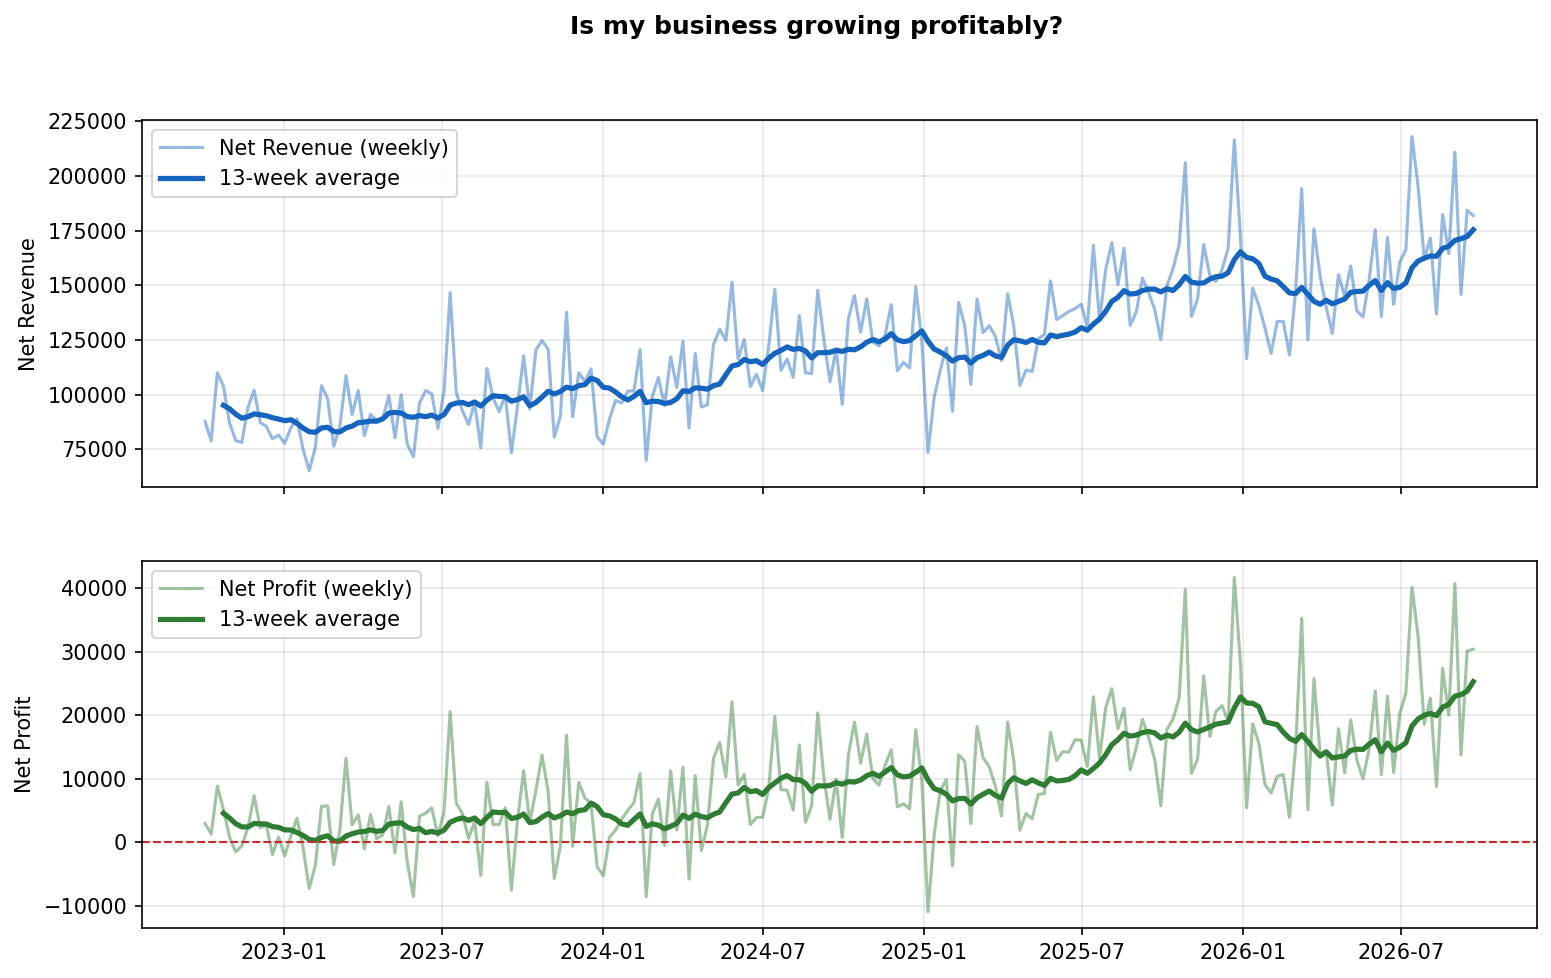

In [11]:
import importlib, src.analytics.eda as _m; importlib.reload(_m)
result = _m.run_eda(config=CONFIG, **context)
context.update(result)
print("✅ EDA | charts:", len(result['chart_paths']))
from IPython.display import Image, display
display(Image(result['chart_paths'][0]))
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

### Phase 5 — `src/models/classifier.py`

In [12]:
%%writefile src/models/classifier.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, compute_thresholds
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import recall_score, precision_score, roc_auc_score, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance


def _label(c):
    return c.replace('_pct', ' %').replace('_', ' ')


def _anomalies(config, df):
    feats = [c for c in config['ANOM_FEATS'] if c in df.columns]
    X = df[feats].replace([np.inf, -np.inf], np.nan)
    med = X.median()
    X = X.fillna(med)
    sc = StandardScaler()
    Z = sc.fit_transform(X)
    iso = IsolationForest(n_estimators=200, contamination=config['ANOMALY_CONT'], random_state=config['RANDOM_STATE'])
    pred = iso.fit_predict(Z)
    df['is_anomaly'] = (pred == -1).astype(int)
    df['anomaly_score'] = -iso.score_samples(Z)
    reasons = []
    for i in range(len(df)):
        if pred[i] != -1:
            reasons.append('')
            continue
        j = int(np.argmax(np.abs(Z[i])))
        side = 'above' if Z[i, j] > 0 else 'below'
        reasons.append(f"{_label(feats[j])} is {abs(Z[i, j]):.1f} std dev {side} normal ({X.iloc[i, j]:.2f} vs typical {med.iloc[j]:.2f})")
    df['anomaly_reason'] = reasons
    return df


def _make_models(rs):
    return {
        'LogisticRegression': lambda: make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000)),
        'GradientBoosting': lambda: GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=rs),
    }


def _fit(name, model, X, y):
    if name == 'GradientBoosting':
        w = np.where(y == 1, (y == 0).sum() / max(1, (y == 1).sum()), 1.0)
        model.fit(X, y, sample_weight=w)
    else:
        model.fit(X, y)
    return model


def _loss_week_model(config, df, thr):
    tgt = config['TARGET_FLAG']
    y = df[tgt].astype(int).reset_index(drop=True)
    feats = [c for c in config['CLF_FEATS'] if c in df.columns]
    X = df[feats].replace([np.inf, -np.inf], np.nan)
    med = X.median()
    X = X.fillna(med).reset_index(drop=True)
    df['loss_risk_rule'] = ((df['promo_flag'] == 1) & (df['discount_rate_pct'] > thr['DISCOUNT_RATE_MAX_PCT'])).astype(int)
    n_loss = int(y.sum())
    rule_recall = float(recall_score(y, df['loss_risk_rule'], zero_division=0))
    report = {'n_loss_weeks': n_loss, 'n_weeks': int(len(y)), 'rule_recall': round(rule_recall, 4),
              'features_used': feats, 'excluded_for_leakage': ['Net_Profit', 'EBITDA', 'Net_Margin_pct', 'Tax', 'Gross_Profit']}
    bundle = {'model': None, 'features': feats, 'medians': med.to_dict(), 'threshold': None,
              'method': 'rule', 'encoders': {}, 'model_name': 'rule'}
    if n_loss < config['LOSS_MIN_WEEKS'] or (len(y) - n_loss) < config['LOSS_MIN_WEEKS']:
        report.update({'method': 'rule', 'skipped': True,
                       'reason': f"Only {n_loss} loss weeks (need {config['LOSS_MIN_WEEKS']}); using rule-based flag."})
        print('  ' + report['reason'])
        joblib.dump(bundle, config['MODEL_CLF'])
        return bundle, report, {}

    tscv = TimeSeriesSplit(n_splits=config['N_SPLITS'])
    results, oof_all = {}, {}
    for name, mk in _make_models(config['RANDOM_STATE']).items():
        oof = np.full(len(y), np.nan)
        for tr, te in tscv.split(X):
            if y.iloc[tr].nunique() < 2 or len(tr) < 30:
                continue
            m = _fit(name, mk(), X.iloc[tr], y.iloc[tr])
            oof[te] = m.predict_proba(X.iloc[te])[:, 1]
        mask = ~np.isnan(oof)
        if mask.sum() == 0 or y[mask].nunique() < 2:
            continue
        best_th, best = None, None
        for th in np.arange(0.05, 0.95, 0.05):
            pr = (oof[mask] >= th).astype(int)
            rec = recall_score(y[mask], pr, zero_division=0)
            prec = precision_score(y[mask], pr, zero_division=0)
            if rec >= config['RECALL_TARGET'] and (best is None or prec > best[1]):
                best_th, best = float(th), (rec, prec)
        if best_th is None:       # target not reachable: take the threshold with best recall (lowest threshold)
            best_th = 0.05
            pr = (oof[mask] >= best_th).astype(int)
            best = (recall_score(y[mask], pr, zero_division=0), precision_score(y[mask], pr, zero_division=0))
        results[name] = {'threshold': round(best_th, 2), 'recall': round(float(best[0]), 4), 'precision': round(float(best[1]), 4),
                         'roc_auc': round(float(roc_auc_score(y[mask], oof[mask])), 4), 'oof_weeks': int(mask.sum())}
        oof_all[name] = best_th
    if not results:
        report.update({'method': 'rule', 'skipped': True, 'reason': 'Time-series folds had no usable loss weeks; using rule-based flag.'})
        joblib.dump(bundle, config['MODEL_CLF'])
        return bundle, report, {}

    chosen = max(results, key=lambda n: (results[n]['recall'] >= config['RECALL_TARGET'], results[n]['roc_auc']))
    final = _fit(chosen, _make_models(config['RANDOM_STATE'])[chosen](), X, y)
    if chosen == 'GradientBoosting':
        imp = pd.Series(final.feature_importances_, index=feats)
    else:
        imp = pd.Series(np.abs(final[-1].coef_[0]), index=feats)
    imp = (imp / imp.sum()).sort_values(ascending=False)
    bundle.update({'model': final, 'threshold': oof_all[chosen], 'method': 'ml', 'model_name': chosen})
    joblib.dump(bundle, config['MODEL_CLF'])
    report.update({'method': 'ml', 'skipped': False, 'candidates': results, 'chosen': chosen,
                   'recall': results[chosen]['recall'], 'precision': results[chosen]['precision'],
                   'roc_auc': results[chosen]['roc_auc'], 'threshold': results[chosen]['threshold'],
                   'recall_target': config['RECALL_TARGET'],
                   'target_met': bool(results[chosen]['recall'] >= config['RECALL_TARGET']),
                   'top_features': {k: round(float(v), 4) for k, v in imp.head(10).items()},
                   'note': 'Metrics are out-of-fold over time-ordered splits; loss_risk_prob on training weeks is in-sample.'})
    print(f"  Loss-week model: {chosen} | recall {report['recall']:.2f} | precision {report['precision']:.2f} | AUC {report['roc_auc']:.2f}")
    return bundle, report, imp.to_dict()


def _driver_model(config, df):
    feats = [c for c in config['DRIVER_FEATS'] if c in df.columns]
    X = df[feats].replace([np.inf, -np.inf], np.nan)
    med = X.median()
    X = X.fillna(med)
    y = df[config['TARGET_PRIMARY']].astype(float)
    T = min(config['TEST_WEEKS'], max(1, len(df) // 4))
    Xtr, Xte, ytr, yte = X.iloc[:-T], X.iloc[-T:], y.iloc[:-T], y.iloc[-T:]
    mk = lambda: GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=config['RANDOM_STATE'])
    m = mk().fit(Xtr, ytr)
    pred = m.predict(Xte)
    r2, mae = float(r2_score(yte, pred)), float(mean_absolute_error(yte, pred))
    pi = permutation_importance(m, Xte, yte, n_repeats=20, random_state=config['RANDOM_STATE'], scoring='neg_mean_absolute_error')
    imp = pd.DataFrame({'feature': feats, 'importance_mean': pi.importances_mean, 'importance_std': pi.importances_std})
    imp = imp.sort_values('importance_mean', ascending=False).reset_index(drop=True)
    pos = imp['importance_mean'].clip(lower=0)
    imp['importance_share'] = pos / pos.sum() if pos.sum() > 0 else 0.0
    share = dict(zip(imp['feature'], imp['importance_share']))
    channel_imp = {}
    for col, sh in zip(config['SPEND_COLS'], config['SHARE_COLS']):
        channel_imp[config['CHANNEL_NAMES'][col]] = float(share.get(col, 0) + share.get(sh, 0))
    group_imp = {'promo': float(sum(share.get(c, 0) for c in ['promo_flag', 'discount_rate_pct'])),
                 'seasonality': float(sum(share.get(c, 0) for c in ['week_of_year', 'is_q4'])),
                 'total_spend': float(share.get('Total_Marketing_Spend', 0))}
    final = mk().fit(X, y)
    joblib.dump({'model': final, 'features': feats, 'medians': med.to_dict()}, config['MODEL_DRIVER'])
    imp.to_csv(config['DRIVER_CSV'], index=False)
    rep = {'holdout_weeks': int(T), 'holdout_r2': round(r2, 4), 'holdout_mae': round(mae, 2),
           'reliable': bool(r2 > 0.2), 'channel_importance': channel_imp, 'group_importance': group_imp,
           'note': 'Permutation importance on the last holdout weeks. Associations, not proven causes.'}
    if not rep['reliable']:
        print(f"  NOTE: driver model holdout R2 {r2:.2f} is weak; channel ranking is indicative only.")
    return rep, imp, channel_imp


def run_classifier(config=CONFIG, df_feat=None, **kwargs):
    """Phase 6: anomaly detection, loss-week classifier, Net_Profit driver model. Outputs: clf_model, clf_report, df_feat, driver_report, channel_importance."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    df = df_feat.copy()
    assert len(df) >= config['MIN_ROWS'], f"Need at least {config['MIN_ROWS']} rows, got {len(df)}"
    thr = kwargs.get('thresholds') or compute_thresholds(config, df)
    df = _anomalies(config, df)
    print(f"  Anomaly weeks flagged: {int(df['is_anomaly'].sum())}")
    bundle, clf_report, clf_imp = _loss_week_model(config, df, thr)
    drv_report, drv_imp, channel_imp = _driver_model(config, df)
    cols = [config['ID_COL'], config['DATE_COL'], 'is_anomaly', 'anomaly_score', 'anomaly_reason', config['TARGET_FLAG'], 'loss_risk_rule']
    df[cols].to_csv(config['ML2_CSV'], index=False)
    return {'clf_model': bundle, 'clf_report': clf_report, 'df_feat': df, 'driver_report': drv_report,
            'driver_importance': drv_imp, 'channel_importance': channel_imp}



Writing src/models/classifier.py


In [13]:
import importlib, src.models.classifier as _m; importlib.reload(_m)
result = _m.run_classifier(config=CONFIG, **context)
context.update(result)
print("✅ Classifier | method:", result['clf_report']['method'], "| anomalies:", int(result['df_feat']['is_anomaly'].sum()))
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Anomaly weeks flagged: 11
  Loss-week model: LogisticRegression | recall 0.92 | precision 0.12 | AUC 0.66
  NOTE: driver model holdout R2 0.01 is weak; channel ranking is indicative only.
✅ Classifier | method: ml | anomalies: 11


### Phase 6 — `src/models/segmentation.py`

In [14]:
%%writefile src/models/segmentation.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG
import numpy as np
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


def _names(k):
    if k == 3:
        return ['Efficient', 'Steady', 'Burn']
    if k == 2:
        return ['Efficient', 'Burn']
    if k == 4:
        return ['Efficient', 'Steady', 'Watch', 'Burn']
    return ['Efficient'] + [f'Tier {i}' for i in range(2, k)] + ['Burn']


def run_segmentation(config=CONFIG, df_feat=None, **kwargs):
    """Phase 5: KMeans week regimes (Efficient / Steady / Burn). Outputs: seg_model, cluster_profile, df_feat, seg_report."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    df = df_feat.copy()
    assert len(df) >= config['MIN_ROWS'], f"Need at least {config['MIN_ROWS']} rows, got {len(df)}"
    feats = [c for c in config['SEG_FEATS'] if c in df.columns]
    X = df[feats].replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    sil = {}
    for k in range(2, 6):
        km = KMeans(n_clusters=k, n_init=10, random_state=config['RANDOM_STATE']).fit(Xs)
        sil[k] = float(silhouette_score(Xs, km.labels_))
    k_cfg = config['N_CLUSTERS']
    best_k = max(sil, key=sil.get)
    k = best_k if sil[best_k] - sil[k_cfg] > config['SILHOUETTE_MARGIN'] else k_cfg
    model = KMeans(n_clusters=k, n_init=10, random_state=config['RANDOM_STATE']).fit(Xs)
    df['cluster'] = model.labels_

    # label by mean Net_Margin_pct (data-derived, best to worst)
    ranking = df.groupby('cluster')['Net_Margin_pct'].mean().sort_values(ascending=False)
    names = _names(k)
    label_map = {int(c): names[i] for i, c in enumerate(ranking.index)}
    tier_map = {int(c): f'TIER_{i + 1}' for i, c in enumerate(ranking.index)}
    df['segment'] = df['cluster'].map(label_map)
    df['segment_tier'] = df['cluster'].map(tier_map)

    prof_cols = feats + ['Net_Margin_pct', 'Net_Profit', 'Net_Revenue']
    prof = df.groupby('segment')[prof_cols].mean()
    prof.insert(0, 'weeks', df.groupby('segment').size())
    prof['loss_week_rate'] = df.groupby('segment')[config['TARGET_FLAG']].mean()
    prof = prof.reindex([label_map[int(c)] for c in ranking.index]).reset_index()

    final_sil = sil[k]
    profit_order_ok = bool(prof['Net_Profit'].is_monotonic_decreasing)
    report = {'k': int(k), 'silhouette_by_k': {int(a): round(b, 4) for a, b in sil.items()},
              'silhouette': round(final_sil, 4), 'silhouette_target': config['SILHOUETTE_TARGET'],
              'target_met': bool(final_sil >= config['SILHOUETTE_TARGET']),
              'k_kept_at_config': bool(k == k_cfg), 'profit_separation_monotonic': profit_order_ok,
              'features': feats, 'label_map': {str(a): b for a, b in label_map.items()}}
    if not report['target_met']:
        print(f"  NOTE: silhouette {final_sil:.3f} below target {config['SILHOUETTE_TARGET']}; regimes overlap, treat as indicative.")

    os.makedirs(config['MODELS_DIR'], exist_ok=True)
    joblib.dump({'model': model, 'scaler': scaler, 'features': feats, 'label_map': label_map}, config['MODEL_SEG'])
    out = df[[config['ID_COL'], config['DATE_COL'], 'cluster', 'segment', 'segment_tier', 'Net_Margin_pct', 'Net_Profit']]
    out.to_csv(config['ML1_CSV'], index=False)
    print(f"  Segmentation k={k} | silhouette={final_sil:.3f} | counts={df['segment'].value_counts().to_dict()}")
    return {'seg_model': model, 'cluster_profile': prof, 'df_feat': df, 'seg_report': report}



Writing src/models/segmentation.py


In [15]:
import importlib, src.models.segmentation as _m; importlib.reload(_m)
result = _m.run_segmentation(config=CONFIG, **context)
context.update(result)
print("✅ Segmentation | k:", result['seg_report']['k'], "| silhouette:", result['seg_report']['silhouette'])
display(result['cluster_profile'].round(2))
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  File "c:\Users\91635\OneDrive\VS STUDIO\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  Segmentation k=3 | silhouette=0.313 | counts={'Efficient': 96, 'Burn': 78, 'Steady': 34}
✅ Segmentation | k: 3 | silhouette: 0.313


,segment,weeks,ROAS,CAC,Gross_Margin_pct,discount_rate_pct,marketing_pct_of_revenue,conversion_rate_pct,Net_Margin_pct,Net_Profit,Net_Revenue,loss_week_rate
0,Efficient,96,7.60,23.79,54.65,3.17,13.27,4.05,10.03,14754.56,135920.78,0.00
1,Steady,34,6.60,22.91,54.66,11.09,15.30,3.85,8.63,12304.00,130443.32,0.00
2,Burn,78,6.05,29.78,54.62,3.25,16.70,3.49,1.56,2610.71,101394.17,0.32


### Phase 7 — `src/models/predictor.py`

In [16]:
%%writefile src/models/predictor.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

YLAGS = ['lag1', 'lag4', 'lag13', 'lag52', 'rm4']


def _ylag_feats(y, i):
    """Lag features for position i from a history list (recursive-safe)."""
    return {'lag1': y[i - 1], 'lag4': y[i - 4], 'lag13': y[i - 13], 'lag52': y[i - 52],
            'rm4': float(np.mean(y[i - 4:i]))}


def _plan_future(df_hist, horizon, config):
    """Assumptions for future weeks: recent average spend, last year's promo calendar and discount depth."""
    n = len(df_hist)
    last = df_hist[config['DATE_COL']].iloc[-1]
    win = df_hist.tail(config['BASELINE_WINDOW_WEEKS'])
    spend = {c: float(win[c].mean()) for c in config['SPEND_COLS']}
    non_promo = df_hist.loc[df_hist['promo_flag'] == 0, 'discount_rate_pct']
    base_disc = float(non_promo.median()) if len(non_promo) else float(df_hist['discount_rate_pct'].median())
    rows = []
    for h in range(1, horizon + 1):
        d = last + pd.Timedelta(weeks=h)
        i = n + h - 1
        j = i - config['SEASONAL_LAG']
        row = dict(spend)
        row[config['TOTAL_SPEND']] = sum(spend.values())
        row['promo_flag'] = int(df_hist['promo_flag'].iloc[j]) if 0 <= j < n else 0
        row['discount_rate_pct'] = float(df_hist['discount_rate_pct'].iloc[j]) if 0 <= j < n else base_disc
        row['week_of_year'] = int(min(d.isocalendar()[1], 52))
        row['is_q4'] = int(d.month >= 10)
        row['t_index'] = i
        row[config['DATE_COL']] = d
        rows.append(row)
    return pd.DataFrame(rows)


def _exog_all(df_hist, horizon, config):
    cols = config['FORECAST_EXOG']
    hist = df_hist[cols].reset_index(drop=True)
    fut = _plan_future(df_hist, horizon, config)[cols]
    return pd.concat([hist, fut], ignore_index=True)


def _design_row(exog, y, i, cols):
    row = {c: float(exog.iloc[i][c]) for c in cols}
    row.update(_ylag_feats(y, i))
    return row


def _fit_model(X, y, config):
    grid = {'max_depth': [2, 3], 'n_estimators': [150, 300]}
    base = GradientBoostingRegressor(learning_rate=0.04, subsample=0.8, random_state=config['RANDOM_STATE'])
    try:
        gs = GridSearchCV(base, grid, cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_absolute_error')
        gs.fit(X, y)
        return gs.best_estimator_
    except Exception:
        return base.set_params(max_depth=2, n_estimators=200).fit(X, y)


def _forecast(df_hist, y_hist, horizon, config, fit_model=True):
    """Train on df_hist and forecast `horizon` weeks recursively. Returns (model_preds, seasonal_naive, ma4, model)."""
    cols = config['FORECAST_EXOG']
    origin = len(df_hist)
    assert origin >= config['MIN_ROWS'], f"Need at least {config['MIN_ROWS']} rows, got {origin}"
    exog = _exog_all(df_hist, horizon, config)
    y = list(map(float, y_hist[:origin]))
    sn = [y[origin + h - config['SEASONAL_LAG']] for h in range(horizon)]
    ma = [float(np.mean(y[-4:]))] * horizon
    if not fit_model:
        return None, sn, ma, None
    start = config['SEASONAL_LAG']
    Xtr = pd.DataFrame([_design_row(exog, y, i, cols) for i in range(start, origin)])
    ytr = np.array(y[start:origin])
    model = _fit_model(Xtr, ytr, config)
    feat_cols = list(Xtr.columns)
    y_ext, preds = list(y), []
    for h in range(horizon):
        i = origin + h
        x = pd.DataFrame([_design_row(exog, y_ext, i, cols)])[feat_cols]
        p = float(model.predict(x)[0])
        y_ext.append(p)
        preds.append(p)
    model.feature_cols_ = feat_cols
    return preds, sn, ma, model


def _metrics(act, pred, target):
    act, pred = np.array(act, float), np.array(pred, float)
    mae = float(mean_absolute_error(act, pred))
    out = {'mae': round(mae, 2), 'r2': round(float(r2_score(act, pred)), 4),
           'wape_pct': round(float(np.abs(act - pred).sum() / max(1e-9, np.abs(act).sum()) * 100), 2)}
    nz = np.abs(act) > 0
    out['mape_pct'] = round(float(np.mean(np.abs(act[nz] - pred[nz]) / np.abs(act[nz])) * 100), 2) if nz.any() else None
    return out


def _backtest(df, target, config):
    y = df[target].values.astype(float)
    n, H, T = len(y), config['FORECAST_HORIZON_WEEKS'], config['TEST_WEEKS']
    act, mod, sn, ma = [], [], [], []
    for o in range(n - T, n, H):
        hh = min(H, n - o)
        m, s, a, _ = _forecast(df.iloc[:o], y[:o], hh, config)
        act += list(y[o:o + hh]); mod += m; sn += s; ma += a
    return np.array(act), np.array(mod), np.array(sn), np.array(ma)


def _score_rows(df, bundle, config):
    if bundle and bundle.get('model') is not None:
        X = df[bundle['features']].replace([np.inf, -np.inf], np.nan).fillna(pd.Series(bundle['medians']))
        df['loss_risk_prob'] = bundle['model'].predict_proba(X)[:, 1]
        df['loss_risk_flag'] = (df['loss_risk_prob'] >= bundle['threshold']).astype(int)
    else:
        df['loss_risk_prob'] = np.nan
        df['loss_risk_flag'] = df.get('loss_risk_rule', 0)
    return df


def _next_week_risk(df, bundle, config):
    """Loss-risk score for the coming week under the stated planning assumptions."""
    plan = _plan_future(df, 1, config).iloc[0].to_dict()
    n = len(df)
    row = {c: plan.get(c) for c in config['SPEND_COLS'] + [config['TOTAL_SPEND'], 'promo_flag', 'discount_rate_pct', 'week_of_year', 'is_q4']}
    tot = row[config['TOTAL_SPEND']]
    for col, sh in zip(config['SPEND_COLS'], config['SHARE_COLS']):
        row[sh] = row[col] / tot if tot else 0.0
    row['weeks_since_last_promo'] = 0 if row['promo_flag'] == 1 else min(int(df['weeks_since_last_promo'].iloc[-1]) + 1, 52)
    for s in config['LAG_SERIES']:
        yv = df[s].values
        for k in config['LAG_WEEKS']:
            row[f'{s}_lag{k}'] = float(yv[n - k])
        row[f'{s}_rm4'] = float(np.mean(yv[n - 4:n]))
    thr = None
    try:
        from config.config import compute_thresholds
        thr = compute_thresholds(config, df)
    except Exception:
        pass
    rule_flag = int(row['promo_flag'] == 1 and thr is not None and row['discount_rate_pct'] > thr['DISCOUNT_RATE_MAX_PCT'])
    if bundle and bundle.get('model') is not None:
        x = pd.DataFrame([row]).reindex(columns=bundle['features'])
        x = x.fillna(pd.Series(bundle['medians']))
        p = float(bundle['model'].predict_proba(x)[0, 1])
        return {'week_start': plan[config['DATE_COL']].strftime('%Y-%m-%d'), 'probability': round(p, 4),
                'threshold': bundle['threshold'], 'at_risk': bool(p >= bundle['threshold']), 'method': 'ml',
                'assumed_promo': int(row['promo_flag'])}
    return {'week_start': plan[config['DATE_COL']].strftime('%Y-%m-%d'), 'probability': None, 'threshold': None,
            'at_risk': bool(rule_flag), 'method': 'rule', 'assumed_promo': int(row['promo_flag'])}


def run_predictor(config=CONFIG, df_feat=None, clf_model=None, **kwargs):
    """Phase 7: score loss-week risk, forecast Net_Revenue and Net_Profit 13 weeks (baselines first). Outputs: df_feat, forecast_df, forecast_report."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    if clf_model is None and os.path.exists(config['MODEL_CLF']):
        clf_model = joblib.load(config['MODEL_CLF'])
    df = df_feat.copy().sort_values(config['DATE_COL']).reset_index(drop=True)
    assert len(df) >= config['MIN_ROWS'], f"Need at least {config['MIN_ROWS']} rows, got {len(df)}"
    H = config['FORECAST_HORIZON_WEEKS']
    q_lo, q_hi = config['FORECAST_BAND']
    df = _score_rows(df, clf_model, config)

    plan = _plan_future(df, H, config)
    fc = pd.DataFrame({config['DATE_COL']: plan[config['DATE_COL']], 'horizon_week': range(1, H + 1),
                       'assumed_promo_flag': plan['promo_flag'], 'assumed_discount_rate_pct': plan['discount_rate_pct']})
    report = {'horizon_weeks': H, 'targets': {}, 'band': '80% prediction band from holdout residual quantiles',
              'assumptions': ['Marketing spend per channel held at the last 13-week average.',
                              "Promo calendar and discount depth repeat the same week of last year.",
                              'Forecast is a planning view, not a guarantee.']}
    models = {}
    for target in [config['TARGET_SECONDARY'], config['TARGET_PRIMARY']]:
        y = df[target].values.astype(float)
        act, mod, sn, ma = _backtest(df, target, config)
        m_mod, m_sn, m_ma = _metrics(act, mod, target), _metrics(act, sn, target), _metrics(act, ma, target)
        best_base = 'seasonal_naive' if m_sn['mae'] <= m_ma['mae'] else 'moving_avg_4w'
        base_mae = min(m_sn['mae'], m_ma['mae'])
        accepted = m_mod['mae'] < base_mae
        chosen_pred = mod if accepted else (sn if best_base == 'seasonal_naive' else ma)
        resid = act - chosen_pred
        lo_q, hi_q = float(np.quantile(resid, q_lo)), float(np.quantile(resid, q_hi))
        if accepted:
            preds, _, _, model = _forecast(df, y, H, config)
            method = 'GradientBoostingRegressor'
            models[target] = model
        else:
            _, sn_f, ma_f, _ = _forecast(df, y, H, config, fit_model=False)
            preds = sn_f if best_base == 'seasonal_naive' else ma_f
            method, models[target] = best_base, None
        preds = np.array(preds, float)
        lo, hi = preds + lo_q, preds + hi_q
        if target == 'Net_Revenue':
            preds, lo, hi = np.maximum(preds, 0), np.maximum(lo, 0), np.maximum(hi, 0)
        fc[f'{target}_forecast'], fc[f'{target}_lo80'], fc[f'{target}_hi80'], fc[f'{target}_method'] = preds, lo, hi, method
        mape = m_mod['mape_pct'] if accepted else (m_sn['mape_pct'] if best_base == 'seasonal_naive' else m_ma['mape_pct'])
        claim = bool(accepted and (target != 'Net_Revenue' or (mape is not None and mape < config['MAPE_TARGET_PCT'])))
        report['targets'][target] = {
            'method': method, 'model_accepted': bool(accepted), 'best_baseline': best_base,
            'holdout_weeks': int(len(act)), 'model_metrics': m_mod, 'seasonal_naive_metrics': m_sn, 'moving_avg_4w_metrics': m_ma,
            'shipped_mape_pct': mape, 'mape_target_pct': config['MAPE_TARGET_PCT'] if target == 'Net_Revenue' else None,
            'mape_target_met': bool(mape is not None and mape < config['MAPE_TARGET_PCT']) if target == 'Net_Revenue' else None,
            'accuracy_claim': claim, 'band_residual_q10': round(lo_q, 2), 'band_residual_q90': round(hi_q, 2),
            'note': ('Model beat the best baseline MAE on the holdout.' if accepted else
                     f'Model did not beat {best_base} MAE on holdout; baseline shipped. No accuracy claim for the model.')}
        if target == 'Net_Profit' and not accepted:
            print(f"  NOTE: Net_Profit model did not beat baseline ({best_base}); shipping baseline with prediction band, no accuracy claim.")
        report['targets'][target]['next_13w_total'] = round(float(preds.sum()), 2)
        report['targets'][target]['last_13w_actual_total'] = round(float(y[-H:].sum()), 2)
        print(f"  {target}: shipped {method} | holdout MAE model {m_mod['mae']:.0f} vs baseline {base_mae:.0f} | MAPE shipped {mape}")

    rev_next = report['targets']['Net_Revenue']['next_13w_total']
    rev_last = report['targets']['Net_Revenue']['last_13w_actual_total']
    chg = (rev_next - rev_last) / rev_last * 100 if rev_last else 0.0
    report['direction'] = {'net_revenue_change_pct_vs_last_13w': round(chg, 2),
                           'label': 'up' if chg > 2 else ('down' if chg < -2 else 'flat')}
    report['next_week_loss_risk'] = _next_week_risk(df, clf_model, config)

    os.makedirs(config['MODELS_DIR'], exist_ok=True)
    joblib.dump({'models': models, 'report': report, 'exog_cols': config['FORECAST_EXOG'],
                 'type': 'GradientBoostingRegressor (or baseline if it won)'}, config['MODEL_FORECAST'])
    fc.to_csv(config['FORECAST_CSV'], index=False)
    ml2 = df[[config['ID_COL'], config['DATE_COL'], 'is_anomaly', 'anomaly_score', 'anomaly_reason',
              config['TARGET_FLAG'], 'loss_risk_rule', 'loss_risk_prob', 'loss_risk_flag']]
    ml2.to_csv(config['ML2_CSV'], index=False)
    df.to_csv(config['FEAT_CSV'], index=False)
    return {'df_feat': df, 'forecast_df': fc, 'forecast_report': report}



Writing src/models/predictor.py


In [17]:
import importlib, src.models.predictor as _m; importlib.reload(_m)
result = _m.run_predictor(config=CONFIG, **context)
context.update(result)
print("✅ Predictor | forecast rows:", len(result['forecast_df']))
display(result['forecast_df'].head())
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Net_Revenue: shipped moving_avg_4w | holdout MAE model 20206 vs baseline 19948 | MAPE shipped 12.04
  Net_Profit: shipped GradientBoostingRegressor | holdout MAE model 7706 vs baseline 8342 | MAPE shipped 48.16
✅ Predictor | forecast rows: 13


,Week_Start,horizon_week,assumed_promo_flag,assumed_discount_rate_pct,Net_Revenue_forecast,Net_Revenue_lo80,Net_Revenue_hi80,Net_Revenue_method,Net_Profit_forecast,Net_Profit_lo80,Net_Profit_hi80,Net_Profit_method
0,2026-09-28,1,0,3.491941,180696.75,157089.0,214318.5,moving_avg_4w,19665.116818,8892.922290,32965.281490,GradientBoostingRegressor
1,2026-10-05,2,0,4.562171,180696.75,157089.0,214318.5,moving_avg_4w,27300.430010,16528.235481,40600.594682,GradientBoostingRegressor
2,2026-10-12,3,0,2.774438,180696.75,157089.0,214318.5,moving_avg_4w,21599.862615,10827.668086,34900.027287,GradientBoostingRegressor
3,2026-10-19,4,1,10.297042,180696.75,157089.0,214318.5,moving_avg_4w,24282.699971,13510.505442,37582.864643,GradientBoostingRegressor
4,2026-10-26,5,1,11.321938,180696.75,157089.0,214318.5,moving_avg_4w,22740.970851,11968.776323,36041.135523,GradientBoostingRegressor


### Phase 8 — `src/analytics/business_logic.py`

In [18]:
%%writefile src/analytics/business_logic.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, safe_div, compute_thresholds
import numpy as np
import pandas as pd
import joblib


# ------------------------------------------------------------------ elasticities
def _log_ols(d, ycol, xlog, extra):
    """Log-log OLS: log(y) ~ log(xlog) + extra. Returns (coef dict, r2)."""
    d = d.copy()
    d['t_scaled'] = d['t_index'] / max(1, len(d)) if 't_index' in d else np.arange(len(d)) / max(1, len(d))
    X = [np.ones(len(d))] + [np.log(d[c].clip(lower=1).values.astype(float)) for c in xlog] + [d[c].values.astype(float) for c in extra]
    X = np.column_stack(X)
    y = np.log(d[ycol].clip(lower=1).values.astype(float))
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    pred = X @ beta
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = float(1 - ((y - pred) ** 2).sum() / ss_tot) if ss_tot > 0 else 0.0
    return dict(zip(['const'] + list(xlog) + list(extra), beta.tolist())), r2


def _elasticities(df, config):
    coefs, r2 = _log_ols(df, 'Net_Revenue', config['SPEND_COLS'], ['promo_flag', 'is_q4', 't_scaled'])
    return {c: float(coefs[c]) for c in config['SPEND_COLS']}, r2


def _marginal_roas(df, config):
    """Marginal revenue per unit spend per channel = elasticity x revenue / spend, recent 52 vs prior 52 weeks."""
    out = {}
    wins = {'recent': df.tail(52), 'prior': df.iloc[-104:-52] if len(df) >= 104 + 10 else None}
    for tag, w in wins.items():
        if w is None or len(w) < 30:
            out[tag] = {c: None for c in config['SPEND_COLS']}
            continue
        el, _ = _elasticities(w, config)
        out[tag] = {c: max(el[c], 0.0) * w['Net_Revenue'].mean() / max(1.0, w[c].mean()) for c in config['SPEND_COLS']}
    return out


# ------------------------------------------------------------------ rules
def _streak(flag):
    flag = flag.astype(int)
    return flag.groupby((flag == 0).cumsum()).cumsum()


def _business_rules(config, df, thr, channel_importance):
    SP, SH, CN = config['SPEND_COLS'], config['SHARE_COLS'], config['CHANNEL_NAMES']
    base_med = float(df.loc[df['promo_flag'] == 0, 'Net_Profit'].median())
    month_tab = df.groupby('month_num')['Net_Margin_pct'].mean()
    best_month = pd.Timestamp(2000, int(month_tab.idxmax()), 1).strftime('%B') if len(month_tab) else 'the strongest month'
    recs = []

    # weekly flags
    bl = df[[config['ID_COL'], config['DATE_COL'], config['PROMO_COL'], 'promo_flag']].copy()
    bl['rule_cut_promo'] = ((df['promo_flag'] == 1) & (df['Net_Profit'] < base_med) & (df['discount_rate_pct'] > thr['DISCOUNT_RATE_MAX_PCT'])).astype(int)
    bl['rule_repeat_promo'] = ((df['promo_flag'] == 1) & (df['Net_Profit'] > base_med)).astype(int)
    below = (df['LTV_to_CAC'] < thr['LTV_CAC_MIN']).astype(int)
    streak = _streak(below)
    bl['ltv_cac_below_streak'] = streak.values
    bl['rule_pause_acquisition'] = (streak >= config['LTV_CAC_STREAK_WEEKS']).astype(int).values
    bl['rule_high_returns'] = (df['return_rate_pct'] > thr['RETURN_RATE_MAX_PCT']).astype(int)

    # promo-level recommendations
    for ev, g in df[df['promo_flag'] == 1].groupby(config['PROMO_COL']):
        med, disc = float(g['Net_Profit'].median()), float(g['discount_rate_pct'].median())
        ev_txt = f"{ev}: median Net_Profit {med:,.0f} vs {base_med:,.0f} in normal weeks; median discount {disc:.1f}% (limit {thr['DISCOUNT_RATE_MAX_PCT']:.1f}%)"
        if med < base_med and disc > thr['DISCOUNT_RATE_MAX_PCT']:
            act, rule, pr = 'Reduce discount depth or drop this promo type', 'promo_unprofitable', 'HIGH'
        elif med > base_med:
            act, rule, pr = f'Repeat this promo; schedule it for the strongest season ({best_month})', 'promo_profitable', 'MEDIUM'
        else:
            act, rule, pr = 'Keep, but test a shallower discount before repeating', 'promo_neutral', 'LOW'
        recs.append({'scope': 'promo', 'subject': ev, 'rule': rule, 'action': act, 'evidence': ev_txt,
                     'weeks': int(len(g)), 'priority': pr, 'outcome': 'DECIDE'})

    # channel rules
    mroas = _marginal_roas(df, config)
    last13 = df.tail(config['BASELINE_WINDOW_WEEKS'])
    share13 = {c: float(last13[s].mean()) for c, s in zip(SP, SH)}
    med_share = float(np.median(list(share13.values())))
    rows = []
    for c, s in zip(SP, SH):
        name = CN[c]
        up = df[c].diff() > 0
        run4 = up.rolling(config['SATURATION_WEEKS']).sum() == config['SATURATION_WEEKS']
        no_lift = df['Orders'].diff(config['SATURATION_WEEKS']) <= 0
        sat = (run4 & no_lift).fillna(False)
        bl[f'saturation_{name.lower()}'] = sat.astype(int).values
        sat_recent = bool(sat.tail(config['BASELINE_WINDOW_WEEKS']).any())
        mr, mp = mroas['recent'][c], mroas['prior'][c]
        rising = mr is not None and mp is not None and mr > mp and mr > 0
        low_share = share13[c] < med_share
        action, rule, pr = 'Hold current budget', 'none', 'LOW'
        if sat_recent:
            action, rule, pr = 'Cap this channel; saturation', 'channel_saturation', 'HIGH'
        elif rising and low_share:
            action, rule, pr = f"Shift {config['SHIFT_BUDGET_PCT']}% of budget here (test)", 'channel_underinvested', 'MEDIUM'
        ev = (f"{name}: share of spend {share13[c] * 100:.1f}% (peer median {med_share * 100:.1f}%); "
              f"marginal return recent {('n/a' if mr is None else f'{mr:.2f}')} vs prior {('n/a' if mp is None else f'{mp:.2f}')}; "
              f"saturation weeks (4 straight rises, no order lift): {int(sat.sum())}")
        if rule != 'none':
            recs.append({'scope': 'channel', 'subject': name, 'rule': rule, 'action': action, 'evidence': ev,
                         'priority': pr, 'outcome': 'DECIDE'})
        rows.append({'channel': name, 'share_last13': share13[c], 'peer_median_share': med_share,
                     'marginal_return_recent': mr, 'marginal_return_prior': mp, 'saturation_weeks': int(sat.sum()),
                     'driver_importance_share': (channel_importance or {}).get(name), 'action': action, 'rule': rule})
    seg_priority = pd.DataFrame(rows)

    # customer economics and returns
    if int(bl['ltv_cac_below_streak'].iloc[-1]) >= config['LTV_CAC_STREAK_WEEKS']:
        recs.append({'scope': 'customer', 'subject': 'LTV_to_CAC', 'rule': 'ltv_cac_below_floor',
                     'action': 'Pause paid acquisition expansion; invest in Email/retention',
                     'evidence': f"LTV_to_CAC below {thr['LTV_CAC_MIN']:.1f} for {int(bl['ltv_cac_below_streak'].iloc[-1])} straight weeks",
                     'priority': 'HIGH', 'outcome': 'DECIDE'})
    n_ret = int(bl['rule_high_returns'].tail(13).sum())
    if n_ret >= 4:
        recs.append({'scope': 'quality', 'subject': 'Returns', 'rule': 'high_return_rate',
                     'action': 'Audit product quality or listing accuracy',
                     'evidence': f"Return rate above {thr['RETURN_RATE_MAX_PCT']:.1f}% in {n_ret} of the last 13 weeks",
                     'priority': 'MEDIUM', 'outcome': 'DECIDE'})

    def week_text(r):
        t = []
        if r['rule_cut_promo']:
            t.append('Reduce discount depth or drop this promo type')
        if r['rule_repeat_promo']:
            t.append('Repeat this promo; schedule it for the strongest season')
        if r['rule_pause_acquisition']:
            t.append('Pause paid acquisition expansion; invest in Email/retention')
        if r['rule_high_returns']:
            t.append('Audit product quality or listing accuracy')
        for c in SP:
            if r[f'saturation_{CN[c].lower()}']:
                t.append(f'Cap {CN[c]}; saturation')
        return '; '.join(t)
    bl['recommendation'] = bl.apply(week_text, axis=1)
    return bl, recs, seg_priority


# ------------------------------------------------------------------ simulations
def _baseline(df, config):
    w, y = df.tail(config['BASELINE_WINDOW_WEEKS']), df.tail(52)
    b = {c: float(w[c].mean()) for c in config['SPEND_COLS']}
    b['total'] = float(sum(b.values()))
    for k, col in [('net_revenue', 'Net_Revenue'), ('net_profit', 'Net_Profit'), ('orders', 'Orders'), ('new_customers', 'New_Customers'),
                   ('gross_revenue', 'Gross_Revenue'), ('cogs', 'COGS'), ('discount_rate_pct', 'discount_rate_pct'), ('return_rate_pct', 'return_rate_pct')]:
        b[k] = float(w[col].mean())
    b['gm_share'] = float(safe_div(y['Gross_Profit'].sum(), y['Net_Revenue'].sum()))
    ts, ps = y['Tax'].sum(), y['Net_Profit'].sum()
    tr = safe_div(ts, ps + ts)
    b['tax_rate'] = float(min(max(tr, 0.0), 0.4)) if (ps + ts) > 0 else 0.25
    return b


def _driver_row(bundle, B, spend, df, config):
    x = {c: B[c] for c in config['SPEND_COLS']}
    x.update(spend)
    tot = sum(x[c] for c in config['SPEND_COLS'])
    x[config['TOTAL_SPEND']] = tot
    for c, s in zip(config['SPEND_COLS'], config['SHARE_COLS']):
        x[s] = x[c] / tot if tot else 0.0
    last = df.tail(config['BASELINE_WINDOW_WEEKS'])
    x['promo_flag'] = float(last['promo_flag'].mean())
    x['discount_rate_pct'] = B['discount_rate_pct']
    x['week_of_year'] = float(df['week_of_year'].iloc[-1])
    x['is_q4'] = float(df['is_q4'].iloc[-1])
    return pd.DataFrame([x]).reindex(columns=bundle['features'])


def _simulations(config, df):
    SP, SH, CN = config['SPEND_COLS'], config['SHARE_COLS'], config['CHANNEL_NAMES']
    B = _baseline(df, config)
    beta, r2 = _elasticities(df, config)
    beta_c = {c: max(v, 0.0) for c, v in beta.items()}
    sims = {}
    driver = None
    if os.path.exists(config['MODEL_DRIVER']):
        try:
            driver = joblib.load(config['MODEL_DRIVER'])
        except Exception:
            driver = None

    # ---- 1. channel budget shift
    rng_share = {c: [float(df[s].min()), float(df[s].max())] for c, s in zip(SP, SH)}
    entries = []
    for i in range(len(SP)):
        for j in range(i + 1, len(SP)):
            for step in config['SHIFT_STEPS_PCT']:
                if step == 0:
                    continue
                frm, to = (SP[i], SP[j]) if step > 0 else (SP[j], SP[i])
                amt = abs(step) / 100.0 * B['total']
                if amt > B[frm]:
                    entries.append({'pair': [CN[SP[i]], CN[SP[j]]], 'from': CN[frm], 'to': CN[to], 'shift_pct_of_budget': abs(step),
                                    'signed_step': step, 'feasible': False})
                    continue
                new = {c: B[c] for c in SP}
                new[frm] -= amt
                new[to] += amt
                mult = float(np.prod([(max(new[c], 1.0) / max(B[c], 1.0)) ** beta_c[c] for c in SP]))
                rev = B['net_revenue'] * mult
                d_rev = rev - B['net_revenue']
                extrap = any(not (rng_share[c][0] <= new[c] / B['total'] <= rng_share[c][1]) for c in SP)
                e = {'pair': [CN[SP[i]], CN[SP[j]]], 'from': CN[frm], 'to': CN[to], 'shift_pct_of_budget': abs(step), 'signed_step': step,
                     'feasible': True, 'new_spend': {CN[c]: round(new[c], 2) for c in SP},
                     'net_revenue': rev, 'delta_net_revenue': d_rev, 'delta_net_profit': d_rev * B['gm_share'],
                     'extrapolation': bool(extrap)}
                if driver is not None:
                    try:
                        p0 = driver['model'].predict(_driver_row(driver, B, {}, df, config).fillna(0))[0]
                        p1 = driver['model'].predict(_driver_row(driver, B, new, df, config).fillna(0))[0]
                        e['driver_model_delta_net_profit'] = float(p1 - p0)
                    except Exception:
                        pass
                entries.append(e)
    sims['channel_budget_shift'] = {
        'meta': {'method': 'Log-log elasticities of Net_Revenue to channel spend (negative values clipped to 0); profit = revenue change x gross margin share, budget-neutral.',
                 'elasticities': {CN[c]: round(v, 4) for c, v in beta.items()}, 'elasticity_model_r2': round(r2, 4),
                 'baseline_weekly': {'net_revenue': B['net_revenue'], 'net_profit': B['net_profit'], 'total_spend': B['total'],
                                     'spend': {CN[c]: B[c] for c in SP}, 'gross_margin_share': B['gm_share']},
                 'caveat': 'Associations from 4 years of weekly data; spend moves with season and promos. Treat as a test hypothesis.',
                 'observed_range': {'channel_share_of_spend': {CN[c]: rng_share[c] for c in SP}}},
        'scenarios': entries}

    # ---- 2. promo discount depth
    coefs, r2d = _log_ols(df, 'Orders', [config['TOTAL_SPEND']], ['discount_rate_pct', 'is_q4', 't_scaled'])
    b_raw = coefs['discount_rate_pct']
    b = max(b_raw, 0.0)
    d0, r_pct = B['discount_rate_pct'], B['return_rate_pct']
    aov_g, cogs_po = safe_div(B['gross_revenue'], B['orders']), safe_div(B['cogs'], B['orders'])
    base_net_model = B['orders'] * aov_g * (1 - d0 / 100 - r_pct / 100)
    lo_d, hi_d = float(df['discount_rate_pct'].min()), float(df['discount_rate_pct'].max())
    pts = []
    for d in np.arange(0, config['DISCOUNT_SIM_MAX_PCT'] + 1e-9, config['DISCOUNT_SIM_STEP_PCT']):
        orders = B['orders'] * float(np.exp(b * (d - d0)))
        net = orders * aov_g * (1 - d / 100 - r_pct / 100)
        cogs = orders * cogs_po
        pretax = (net - base_net_model) - (cogs - B['cogs'])
        pts.append({'discount_rate_pct': float(d), 'orders': orders, 'net_revenue': B['net_revenue'] + (net - base_net_model),
                    'net_profit': B['net_profit'] + pretax * (1 - B['tax_rate']), 'extrapolation': bool(d < lo_d or d > hi_d)})
    sims['promo_discount_depth'] = {
        'meta': {'method': 'Orders respond to discount depth with the observed log-linear response (controls: total spend, Q4, trend). COGS scales with orders, not with discounts.',
                 'orders_per_discount_point_pct': round(b_raw * 100, 3), 'clipped_to_zero': bool(b_raw < 0), 'model_r2': round(r2d, 4),
                 'baseline_discount_rate_pct': d0,
                 'baseline_weekly': {'orders': B['orders'], 'net_revenue': B['net_revenue'], 'net_profit': B['net_profit']},
                 'caveat': 'Points outside observed_range are extrapolation.',
                 'observed_range': {'discount_rate_pct': [lo_d, hi_d],
                                    'promo_weeks_discount_rate_pct': [float(df.loc[df['promo_flag'] == 1, 'discount_rate_pct'].min()) if (df['promo_flag'] == 1).any() else None,
                                                                      float(df.loc[df['promo_flag'] == 1, 'discount_rate_pct'].max()) if (df['promo_flag'] == 1).any() else None]}},
        'scenarios': pts}

    # ---- 3. marketing % of revenue cap
    sigma = float(sum(beta_c.values()))
    cn, _ = _log_ols(df, 'New_Customers', [config['TOTAL_SPEND']], ['promo_flag', 'is_q4', 't_scaled'])
    gamma = max(cn[config['TOTAL_SPEND']], 0.0)
    mpr = df['marketing_pct_of_revenue']
    lo_m, hi_m = float(mpr.quantile(0.05)), float(mpr.quantile(0.95))
    base_mpr = safe_div(B['total'], B['net_revenue']) * 100
    caps = sorted(set([round(x, 1) for x in np.linspace(lo_m * 0.8, hi_m, 8)] + [round(base_mpr, 1)]))
    spend_rng = [float(df[config['TOTAL_SPEND']].min()), float(df[config['TOTAL_SPEND']].max())]
    out = []
    for cap in caps:
        binding = base_mpr > cap
        if not binding:
            k = 1.0
        elif sigma < 0.999:
            k = (cap / base_mpr) ** (1.0 / (1.0 - sigma))
        else:
            k = cap / base_mpr
        k = float(min(max(k, 0.3), 1.0))
        spend_new = B['total'] * k
        rev_new = B['net_revenue'] * k ** sigma
        out.append({'cap_marketing_pct_of_revenue': cap, 'binding': bool(binding), 'spend_multiplier': k, 'weekly_spend': spend_new,
                    'net_revenue': rev_new, 'marketing_pct_of_revenue': safe_div(spend_new, rev_new) * 100,
                    'new_customers': B['new_customers'] * k ** gamma,
                    'net_profit': B['net_profit'] + (rev_new - B['net_revenue']) * B['gm_share'] - (spend_new - B['total']),
                    'cap_reached': bool(safe_div(spend_new, rev_new) * 100 <= cap + 0.05),
                    'extrapolation': bool(spend_new < spend_rng[0] or spend_new > spend_rng[1] or k <= 0.3)})
    sims['cac_cap_scenarios'] = {
        'meta': {'method': 'All channels scaled together until marketing_pct_of_revenue hits the cap; revenue and new customers follow observed elasticities.',
                 'revenue_elasticity_to_total_spend': round(sigma, 4), 'new_customer_elasticity_to_total_spend': round(gamma, 4),
                 'baseline_marketing_pct_of_revenue': base_mpr,
                 'baseline_weekly': {'net_revenue': B['net_revenue'], 'net_profit': B['net_profit'], 'new_customers': B['new_customers'], 'total_spend': B['total']},
                 'caveat': 'A cap only reduces spend; revenue loss is estimated, not guaranteed. If revenue elasticity to spend is >= 1, a cap cannot be reached by scaling (cap_reached = false).',
                 'observed_range': {'marketing_pct_of_revenue': [lo_m, hi_m], 'weekly_total_spend': spend_rng}},
        'scenarios': out}
    return sims


# ------------------------------------------------------------------ goals and alerts
def _goals_alerts(config, df, thr, forecast_report):
    path = config['GOALS_JSON']
    if os.path.exists(path):
        import json
        with open(path, 'r', encoding='utf-8') as f:
            goals = json.load(f)
    else:
        goals = config['GOAL_DEFAULTS']
        save_json(path, goals)
    last, last4, prior4 = df.iloc[-1], df.tail(4), df.iloc[-8:-4]
    gv = lambda k, d=None: (goals.get(k, {}) or {}).get('value', d)
    prog = {}
    for key, col in [('net_profit_target', 'Net_Profit'), ('net_revenue_target', 'Net_Revenue')]:
        tgt = gv(key)
        actual4 = float(last4[col].mean())
        prog[key] = {'target': tgt, 'unit': 'weekly', 'actual_last_week': float(last[col]), 'actual_4w_avg': actual4,
                     'progress_pct': (actual4 / tgt * 100) if tgt else None,
                     'status': 'not_set' if tgt is None else ('on_track' if actual4 >= tgt else 'behind')}
    floor_w, ltv_min = gv('cash_floor_weeks', 8), gv('ltv_cac_min', 3.0)
    prog['cash_floor_weeks'] = {'target': floor_w, 'actual': float(last['cash_runway_weeks']),
                                'status': 'on_track' if last['cash_runway_weeks'] >= floor_w else 'breach'}
    prog['ltv_cac_min'] = {'target': ltv_min, 'actual_4w_avg': float(last4['LTV_to_CAC'].mean()),
                           'status': 'on_track' if last4['LTV_to_CAC'].mean() >= ltv_min else 'breach'}

    alerts = []

    def add(aid, sev, metric, value, threshold, msg):
        alerts.append({'id': aid, 'severity': sev, 'metric': metric, 'value': value, 'threshold': threshold,
                       'message': msg, 'outcome': 'MONITOR'})
    drop_lim = gv('alert_revenue_drop_pct', 20)
    r4, p4 = float(last4['Net_Revenue'].sum()), float(prior4['Net_Revenue'].sum())
    chg = (r4 - p4) / p4 * 100 if p4 else 0.0
    if chg <= -drop_lim:
        add('revenue_drop', 'HIGH', 'Net_Revenue 4-week change %', chg, -drop_lim, f'4-week Net Revenue is {abs(chg):.1f}% below the prior 4 weeks.')
    if last['cash_runway_weeks'] < floor_w:
        add('runway_low', 'HIGH', 'cash_runway_weeks', float(last['cash_runway_weeks']), floor_w, f"Cash covers {last['cash_runway_weeks']:.1f} weeks of costs, below the {floor_w} week floor.")
    if last['DSO_Days'] > thr['DSO_MAX_DAYS']:
        add('dso_high', 'MEDIUM', 'DSO_Days', float(last['DSO_Days']), thr['DSO_MAX_DAYS'], f"DSO {last['DSO_Days']:.1f} days is above the limit of {thr['DSO_MAX_DAYS']:.1f}.")
    if last4['LTV_to_CAC'].mean() < ltv_min:
        add('ltv_cac_breach', 'HIGH', 'LTV_to_CAC 4-week avg', float(last4['LTV_to_CAC'].mean()), ltv_min, 'Acquisition is not paying back (LTV_to_CAC below the floor).')
    nxt = (forecast_report or {}).get('next_week_loss_risk')
    if nxt and nxt.get('at_risk'):
        add('loss_risk_next_week', 'MEDIUM', 'loss_risk_next_week', nxt.get('probability'), nxt.get('threshold'),
            f"Next week ({nxt.get('week_start')}) is flagged at risk of a loss under the planned promo and spend assumptions.")
    return goals, prog, alerts


def run_business_logic(config=CONFIG, df_feat=None, agg_promo=None, **kwargs):
    """Phase 8: rule-based actions, simulation lookups, goals and alerts. Outputs: seg_priority, recommendations, simulations, goal_progress, alerts."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    df = df_feat.copy().sort_values(config['DATE_COL']).reset_index(drop=True)
    thr = kwargs.get('thresholds') or compute_thresholds(config, df)
    bl, recs, seg_priority = _business_rules(config, df, thr, kwargs.get('channel_importance'))
    bl.to_csv(config['BL_CSV'], index=False)
    sims = _simulations(config, df)
    goals, goal_progress, alerts = _goals_alerts(config, df, thr, kwargs.get('forecast_report'))
    print(f"  Business logic: {len(recs)} recommendations | {len(sims)} simulation sets | {len(alerts)} alerts")
    return {'business_logic_df': bl, 'recommendations': recs, 'seg_priority': seg_priority, 'simulations': sims,
            'goals': goals, 'goal_progress': goal_progress, 'alerts': alerts}



Writing src/analytics/business_logic.py


In [19]:
import importlib, src.analytics.business_logic as _m; importlib.reload(_m)
result = _m.run_business_logic(config=CONFIG, **context)
context.update(result)
print("✅ Business Logic | recommendations:", len(result['recommendations']), "| alerts:", len(result['alerts']))
display(result['seg_priority'].round(3))
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Business logic: 9 recommendations | 3 simulation sets | 0 alerts
✅ Business Logic | recommendations: 9 | alerts: 0


,channel,share_last13,peer_median_share,marginal_return_recent,marginal_return_prior,saturation_weeks,driver_importance_share,action,rule
0,Search,0.413,0.249,0.000,4.783,2,0.307,Hold current budget,none
1,Social,0.334,0.249,1.658,1.081,0,0.174,Hold current budget,none
2,Email,0.088,0.249,22.494,21.175,1,0.227,Shift 10% of budget here (test),channel_underinvested
3,Display,0.165,0.249,18.772,10.639,1,0.037,Shift 10% of budget here (test),channel_underinvested


### Phase 9 — `src/analytics/insights.py`

In [20]:
%%writefile src/analytics/insights.py
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, safe_div, compute_thresholds
import numpy as np
import pandas as pd


def _n(v, d=0):
    return f"{v:,.{d}f}"


def run_insights(config=CONFIG, df_feat=None, agg_promo=None, agg_month=None, **kwargs):
    """Phase 9: >=8 insights computed live, top 3 HIGH. Outputs: insights (list). Saved to reports/insights.json."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    df = df_feat.copy().sort_values(config['DATE_COL']).reset_index(drop=True)
    thr = kwargs.get('thresholds') or compute_thresholds(config, df)
    seg_priority = kwargs.get('seg_priority')
    channel_imp = kwargs.get('channel_importance') or {}
    drv = kwargs.get('driver_report') or {}
    fcr = kwargs.get('forecast_report') or {}
    clf = kwargs.get('clf_report') or {}
    CN = config['CHANNEL_NAMES']
    items = []

    def add(cat, finding, evidence, action, metric, impact):
        items.append({'category': cat, 'finding': finding, 'evidence': evidence, 'action': action,
                      'metric_value': float(metric) if metric is not None and np.isfinite(metric) else 0.0,
                      'outcome': 'DECIDE', '_impact': float(impact)})

    scale = float(df['Net_Profit'].abs().mean()) + 1.0

    # 1. Promo vs non-promo profit gap
    promo, non = df[df['promo_flag'] == 1], df[df['promo_flag'] == 0]
    if len(promo) and len(non):
        gap = float(promo['Net_Profit'].median() - non['Net_Profit'].median())
        loss_p = float(promo[config['TARGET_FLAG']].mean() * 100)
        loss_n = float(non[config['TARGET_FLAG']].mean() * 100)
        word = 'earn more' if gap >= 0 else 'earn less'
        add('Promo Profitability',
            f"Promo weeks {word} than normal weeks by {_n(abs(gap))} in median Net Profit.",
            f"Median Net Profit {_n(promo['Net_Profit'].median())} in {len(promo)} promo weeks vs {_n(non['Net_Profit'].median())} in {len(non)} normal weeks; loss-week rate {loss_p:.0f}% vs {loss_n:.0f}%.",
            'Keep promos that clear the normal-week profit level and cut discount depth on those that do not.' if gap < 0 else
            'Promos are profitable overall; protect depth limits and repeat the best events.',
            gap, min(1, abs(gap) / scale) + (0.25 if gap < 0 else 0.0))

    # 2. Best / worst promo type
    ap = agg_promo if agg_promo is not None else None
    if ap is not None:
        pe = ap[(ap[config['PROMO_COL']] != 'None') & (ap['weeks'] >= 2)]
        if len(pe) >= 2:
            b, w = pe.iloc[0], pe.iloc[-1]
            add('Promo Profitability',
                f"{b[config['PROMO_COL']]} is the strongest promo and {w[config['PROMO_COL']]} the weakest.",
                f"Median Net Profit {_n(b['median_net_profit'])} ({int(b['weeks'])} weeks) vs {_n(w['median_net_profit'])} ({int(w['weeks'])} weeks); weakest runs at {w['median_discount_rate_pct']:.1f}% median discount.",
                f"Repeat {b[config['PROMO_COL']]}; reprice or drop {w[config['PROMO_COL']]}.",
                float(b['median_net_profit'] - w['median_net_profit']),
                min(1, float(b['median_net_profit'] - w['median_net_profit']) / (2 * scale)))

    # 3. Channel driver importance
    if channel_imp:
        ordered = sorted(channel_imp.items(), key=lambda kv: kv[1], reverse=True)
        best, worst = ordered[0], ordered[-1]
        rel = 'reliable enough to act on' if drv.get('reliable') else 'weak (holdout R2 low), so treat as a hint to test'
        add('Channel Performance',
            f"{best[0]} spend is most associated with Net Profit; {worst[0]} the least.",
            f"Permutation importance share: {best[0]} {best[1] * 100:.0f}%, {worst[0]} {worst[1] * 100:.0f}%. Driver model holdout R2 {drv.get('holdout_r2', float('nan')):.2f}: {rel}.",
            f"Test a small budget move toward {best[0]} and watch weekly profit before scaling.",
            best[1], 0.35 + 0.4 * best[1] + (0.1 if drv.get('reliable') else 0.0))

    # 4. Marginal return by channel
    if seg_priority is not None and len(seg_priority) and seg_priority['marginal_return_recent'].notna().any():
        sp = seg_priority.dropna(subset=['marginal_return_recent']).sort_values('marginal_return_recent', ascending=False)
        top, bot = sp.iloc[0], sp.iloc[-1]
        add('Channel Performance',
            f"{top['channel']} returns the most revenue per extra unit of spend recently; {bot['channel']} the least.",
            f"Marginal return {top['marginal_return_recent']:.2f} ({top['channel']}, {top['share_last13'] * 100:.0f}% of spend) vs {bot['marginal_return_recent']:.2f} ({bot['channel']}, {bot['share_last13'] * 100:.0f}% of spend). Associated with, not proof of, cause.",
            f"Rule check: {top['action']} for {top['channel']}; {bot['action'].lower()} for {bot['channel']}.",
            float(top['marginal_return_recent']), 0.45)

    # 5. LTV_to_CAC trend
    l13, p13 = df['LTV_to_CAC'].tail(13).mean(), df['LTV_to_CAC'].iloc[-26:-13].mean()
    below = int((df['LTV_to_CAC'] < thr['LTV_CAC_MIN']).sum())
    d = (l13 - p13) / p13 * 100 if p13 else 0.0
    add('Customer Economics',
        f"LTV to CAC is {'improving' if d > 1 else ('declining' if d < -1 else 'stable')} at {l13:.1f} (last 13 weeks).",
        f"{l13:.2f} vs {p13:.2f} in the prior 13 weeks ({d:+.1f}%); {below} weeks below the {thr['LTV_CAC_MIN']:.1f} floor of {len(df)}.",
        'Acquisition pays back; keep funding it while watching CAC.' if l13 >= thr['LTV_CAC_MIN'] else 'Pause paid acquisition expansion and invest in Email/retention.',
        l13, 0.9 if l13 < thr['LTV_CAC_MIN'] else min(0.5, abs(d) / 50 + 0.2))

    # 6. Retention vs acquisition
    rr13, rrp = df['Repeat_Customer_Rate_pct'].tail(13).mean(), df['Repeat_Customer_Rate_pct'].iloc[-26:-13].mean()
    ns13 = df['new_customer_share'].tail(13).mean() * 100
    add('Customer Economics',
        f"{ns13:.0f}% of recent orders come from new customers; repeat rate is {rr13:.1f}%.",
        f"Repeat customer rate {rr13:.1f}% vs {rrp:.1f}% in the prior 13 weeks; new-customer share of orders {ns13:.1f}%.",
        'Shift effort toward retention (Email, loyalty) if growth depends mostly on paid acquisition.' if ns13 > 50 else 'Retention is carrying a good part of orders; protect it.',
        rr13, 0.4)

    # 7. Cash runway
    run_now = float(df['cash_runway_weeks'].iloc[-1])
    floor = config['THRESHOLDS']['CASH_FLOOR_WEEKS']
    mn = float(df['cash_runway_weeks'].min())
    add('Cash & Collections',
        f"Cash covers {run_now:.1f} weeks of payroll, opex and marketing ({'above' if run_now >= floor else 'BELOW'} the {floor:.0f}-week floor).",
        f"Cash balance {_n(df['Cash_Balance'].iloc[-1])}; lowest runway in history {mn:.1f} weeks; weeks under the floor: {int((df['cash_runway_weeks'] < floor).sum())}.",
        'Cash is safe; keep the floor as a guardrail for any spend increase.' if run_now >= floor else 'Slow discretionary spend and chase receivables until runway recovers.',
        run_now, 0.95 if run_now < floor else 0.3)

    # 8. DSO / collections
    dso_now, dso_avg = float(df['DSO_Days'].iloc[-1]), float(df['DSO_Days'].mean())
    add('Cash & Collections',
        f"Collections take {dso_now:.1f} days (history average {dso_avg:.1f}, limit {thr['DSO_MAX_DAYS']:.1f}).",
        f"AR outstanding {_n(df['AR_Outstanding'].iloc[-1])}; DSO above the limit in {int((df['DSO_Days'] > thr['DSO_MAX_DAYS']).sum())} of {len(df)} weeks.",
        'Chase receivables now.' if dso_now > thr['DSO_MAX_DAYS'] else 'Collections are within the normal range; keep monitoring.',
        dso_now, 0.65 if dso_now > thr['DSO_MAX_DAYS'] else 0.2)

    # 9. Seasonality
    am = agg_month if agg_month is not None else None
    if am is not None and len(am) >= 2:
        s, w = am.loc[am['avg_net_margin_pct'].idxmax()], am.loc[am['avg_net_margin_pct'].idxmin()]
        add('Seasonality',
            f"{s['month']} is the strongest month and {w['month']} the weakest by net margin.",
            f"Average Net Margin {s['avg_net_margin_pct']:.1f}% in {s['month']} vs {w['avg_net_margin_pct']:.1f}% in {w['month']}; loss-week rate {s['loss_week_rate'] * 100:.0f}% vs {w['loss_week_rate'] * 100:.0f}%.",
            f"Schedule big promos in or near {s['month']}; hold spend steady in {w['month']}.",
            float(s['avg_net_margin_pct'] - w['avg_net_margin_pct']), min(1, float(s['avg_net_margin_pct'] - w['avg_net_margin_pct']) / 20 + 0.3))

    # 10. Return rate
    ret13 = float(df['return_rate_pct'].tail(13).mean())
    n_hi = int((df['return_rate_pct'] > thr['RETURN_RATE_MAX_PCT']).sum())
    add('Customer Economics',
        f"Return rate is {ret13:.1f}% of gross revenue recently (limit {thr['RETURN_RATE_MAX_PCT']:.1f}%).",
        f"{n_hi} of {len(df)} weeks above the limit; returns cost {_n(df['Returns'].tail(13).sum())} over the last 13 weeks.",
        'Audit product quality or listing accuracy.' if ret13 > thr['RETURN_RATE_MAX_PCT'] else 'Returns are in the normal range; keep tracking after promos.',
        ret13, 0.6 if ret13 > thr['RETURN_RATE_MAX_PCT'] else 0.25)

    # 11. Anomalies
    if 'is_anomaly' in df.columns:
        an = df[df['is_anomaly'] == 1].sort_values('anomaly_score', ascending=False)
        ex = '; '.join(f"{r[config['ID_COL']]}: {r['anomaly_reason']}" for _, r in an.head(2).iterrows())
        add('Channel Performance',
            f"{len(an)} unusual weeks were flagged ({len(an) / len(df) * 100:.0f}% of history).",
            ex if ex else 'No anomalies.', 'Review the flagged weeks for tracking errors, stock-outs or one-off events before using them in plans.',
            len(an), 0.35)

    # 12. Forecast direction
    t = (fcr.get('targets') or {})
    if 'Net_Revenue' in t:
        r, p = t['Net_Revenue'], t.get('Net_Profit', {})
        chg = (fcr.get('direction') or {}).get('net_revenue_change_pct_vs_last_13w', 0.0)
        pt = p.get('next_13w_total')
        add('Seasonality',
            f"Next 13 weeks Net Revenue is forecast {('up' if chg > 0 else 'down')} {abs(chg):.1f}% vs the last 13 weeks.",
            f"Forecast {_n(r['next_13w_total'])} vs {_n(r['last_13w_actual_total'])} actual; method {r['method']}; Net Profit forecast {_n(pt) if pt is not None else 'n/a'} (method {p.get('method', 'n/a')}). Accuracy claim: revenue {r['accuracy_claim']}, profit {p.get('accuracy_claim')}.",
            'Plan the quarter on the forecast band, not a single number.', chg, min(1, abs(chg) / 25 + 0.3))

    # 13. Loss weeks and early warning
    n_loss = int(df[config['TARGET_FLAG']].sum())
    if clf:
        meth = clf.get('method')
        ev = (f"{n_loss} loss weeks of {len(df)}. Early-warning model ({clf.get('chosen')}): recall {clf.get('recall', 0) * 100:.0f}%, precision {clf.get('precision', 0) * 100:.0f}% (out-of-fold)."
              if meth == 'ml' else f"{n_loss} loss weeks of {len(df)}. {clf.get('reason', 'Rule-based flag only.')}")
    else:
        ev = f"{n_loss} loss weeks of {len(df)}."
    add('Promo Profitability', f"{n_loss} weeks lost money ({n_loss / len(df) * 100:.0f}% of history).", ev,
        'Review planned promo weeks flagged at risk before launch; confirm discount depth against the limit.', n_loss,
        min(1, n_loss / len(df) * 2.5))

    # severity: top 3 HIGH, next 5 MEDIUM, rest LOW
    items.sort(key=lambda x: x['_impact'], reverse=True)
    out = []
    for i, it in enumerate(items):
        it['severity'] = 'HIGH' if i < 3 else ('MEDIUM' if i < 8 else 'LOW')
        it['id'] = f'I{i + 1}'
        it.pop('_impact')
        out.append({k: it[k] for k in ['id', 'category', 'severity', 'finding', 'evidence', 'action', 'outcome', 'metric_value']})
    assert len(out) >= 8, 'Need at least 8 insights'
    save_json(config['INSIGHTS_JSON'], out)
    print(f"  Insights: {len(out)} | HIGH {sum(i['severity'] == 'HIGH' for i in out)} | saved {config['INSIGHTS_JSON']}")
    return {'insights': out}



Writing src/analytics/insights.py


In [21]:
import importlib, src.analytics.insights as _m; importlib.reload(_m)
result = _m.run_insights(config=CONFIG, **context)
context.update(result)
print("✅ Insights |", len(result['insights']), "insights")
for i in result['insights'][:3]: print(" -", i['severity'], i['finding'])
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Insights: 13 | HIGH 3 | saved c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\reports\insights.json
✅ Insights | 13 insights
 - HIGH Mid-Year Sale is the strongest promo and Spring Launch the weakest.
 - HIGH Jul is the strongest month and Jan the weakest by net margin.
 - HIGH LTV to CAC is improving at 9.7 (last 13 weeks).


### Phase 10 — `src/reporting/export.py`

In [22]:
%%writefile src/reporting/export.py
import os, sys, json, datetime
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../')))
from config.config import CONFIG, save_json, safe_div, compute_thresholds, rel
import numpy as np
import pandas as pd

WS_COLS = {'Week_Start': 'Week Start', 'Promo_Event': 'Promo', 'Total_Marketing_Spend': 'Marketing Spend', 'Orders': 'Orders',
           'Net_Revenue': 'Net Revenue', 'Net_Profit': 'Net Profit', 'Net_Margin_pct': 'Net Margin %', 'ROAS': 'ROAS', 'CAC': 'CAC',
           'LTV_to_CAC': 'LTV to CAC', 'segment': 'Week regime', 'is_anomaly': 'Unusual week', 'loss_risk_flag': 'Loss risk flag'}


# ------------------------------------------------------------------ Excel
def _style(ws):
    from openpyxl.styles import PatternFill, Font, Alignment
    fill, font = PatternFill('solid', fgColor='1565C0'), Font(bold=True, color='FFFFFF')
    for c in ws[1]:
        c.fill, c.font, c.alignment = fill, font, Alignment(wrap_text=True, vertical='center')
    ws.freeze_panes = 'A2'
    for col in ws.columns:
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:60])
        ws.column_dimensions[col[0].column_letter].width = min(max(10, width + 2), 60)


def _excel(config, df, ctx):
    path = config['EXCEL_PATH']
    os.makedirs(os.path.dirname(path), exist_ok=True)
    d = df.copy()
    d[config['DATE_COL']] = pd.to_datetime(d[config['DATE_COL']]).dt.date
    ws = d[[c for c in WS_COLS if c in d.columns]].rename(columns=WS_COLS).iloc[::-1].round(2)
    ch = ctx.get('seg_priority')
    if ch is None or len(ch) == 0:
        ch = ctx.get('agg_channel', pd.DataFrame())
    ch = ch.rename(columns={c: c.replace('_', ' ').capitalize() for c in ch.columns}).round(3)
    pa = ctx.get('agg_promo', pd.DataFrame())
    pa = pa.rename(columns={c: c.replace('_', ' ').capitalize() for c in pa.columns}).round(2)
    cash = d[[config['DATE_COL'], 'Cash_Balance', 'AR_Outstanding', 'DSO_Days', 'cash_runway_weeks']].rename(
        columns={config['DATE_COL']: 'Week Start', 'Cash_Balance': 'Cash Balance', 'AR_Outstanding': 'AR Outstanding',
                 'DSO_Days': 'DSO Days', 'cash_runway_weeks': 'Cash runway (weeks)'}).iloc[::-1].round(2)
    fc = ctx.get('forecast_df', pd.DataFrame()).copy()
    if len(fc) and config['DATE_COL'] in fc:
        fc[config['DATE_COL']] = pd.to_datetime(fc[config['DATE_COL']]).dt.date
    fc = fc.rename(columns={c: c.replace('_', ' ') for c in fc.columns}).round(2)
    rows = []
    for r in ctx.get('recommendations', []):
        rows.append({'Priority': r['priority'], 'Area': r['scope'].title(), 'Subject': r['subject'], 'Action': r['action'], 'Evidence': r['evidence']})
    for i in ctx.get('insights', []):
        rows.append({'Priority': i['severity'], 'Area': i['category'], 'Subject': i['finding'], 'Action': i['action'], 'Evidence': i['evidence']})
    order = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
    actions = pd.DataFrame(rows)
    if len(actions):
        actions = actions.sort_values('Priority', key=lambda s: s.map(order)).reset_index(drop=True)
    with pd.ExcelWriter(path, engine='openpyxl') as xw:
        for name, frame in [('Weekly Summary', ws), ('Channel Performance', ch), ('Promo Analysis', pa),
                            ('Cash & Collections', cash), ('13-Week Outlook', fc), ('Action List', actions)]:
            (frame if len(frame) else pd.DataFrame({'Note': ['No data for this sheet in this run']})).to_excel(xw, sheet_name=name, index=False)
            _style(xw.sheets[name])
    return path


def _html(config, df, ctx):
    try:
        import plotly.graph_objects as go
    except Exception:
        return None
    try:
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=df[config['DATE_COL']], y=df['Net_Revenue'], name='Net Revenue'))
        fig.add_trace(go.Scatter(x=df[config['DATE_COL']], y=df['Net_Profit'], name='Net Profit'))
        fc = ctx.get('forecast_df')
        if fc is not None and len(fc):
            fig.add_trace(go.Scatter(x=fc[config['DATE_COL']], y=fc['Net_Revenue_forecast'], name='Net Revenue forecast', line=dict(dash='dash')))
            fig.add_trace(go.Scatter(x=fc[config['DATE_COL']], y=fc['Net_Profit_forecast'], name='Net Profit forecast', line=dict(dash='dash')))
        fig.update_layout(title='Weekly Growth & Profit with 13-week outlook', template='plotly_white')
        fig.write_html(config['HTML_PATH'], include_plotlyjs='cdn')
        return config['HTML_PATH']
    except Exception as e:
        print(f"  HTML dashboard skipped: {e}")
        return None


# ------------------------------------------------------------------ frontend export
def _kpis(df, config):
    H = config['BASELINE_WINDOW_WEEKS']
    a, b = df.tail(H), df.iloc[-2 * H:-H]

    def entry(key, label, v, pv, unit, period):
        ch = ((v - pv) / abs(pv) * 100) if (pv is not None and pv != 0) else None
        return {'key': key, 'label': label, 'value': v, 'prior_value': pv, 'change_pct': ch, 'unit': unit, 'period': period}
    pw = f'last {H} weeks'
    rev, prev = float(a['Net_Revenue'].sum()), float(b['Net_Revenue'].sum()) if len(b) else None
    prof, prof_p = float(a['Net_Profit'].sum()), float(b['Net_Profit'].sum()) if len(b) else None
    marg = float(safe_div(a['Net_Profit'].sum(), a['Net_Revenue'].sum()) * 100)
    marg_p = float(safe_div(b['Net_Profit'].sum(), b['Net_Revenue'].sum()) * 100) if len(b) else None
    roas = float(safe_div(a['Net_Revenue'].sum(), a[config['TOTAL_SPEND']].sum()))
    roas_p = float(safe_div(b['Net_Revenue'].sum(), b[config['TOTAL_SPEND']].sum())) if len(b) else None
    cash_p = float(df['Cash_Balance'].iloc[-H - 1]) if len(df) > H else None
    run_p = float(df['cash_runway_weeks'].iloc[-H - 1]) if len(df) > H else None
    k = [entry('net_revenue', 'Net Revenue', rev, prev, 'currency', pw),
         entry('net_profit', 'Net Profit', prof, prof_p, 'currency', pw),
         entry('net_margin_pct', 'Net Margin %', marg, marg_p, 'percent', pw),
         entry('roas', 'ROAS', roas, roas_p, 'ratio', pw),
         entry('cac', 'CAC', float(a['CAC'].mean()), float(b['CAC'].mean()) if len(b) else None, 'currency', pw),
         entry('ltv_to_cac', 'LTV to CAC', float(a['LTV_to_CAC'].mean()), float(b['LTV_to_CAC'].mean()) if len(b) else None, 'ratio', pw),
         entry('cash_balance', 'Cash Balance', float(df['Cash_Balance'].iloc[-1]), cash_p, 'currency', 'latest week'),
         entry('cash_runway_weeks', 'Cash runway (weeks)', float(df['cash_runway_weeks'].iloc[-1]), run_p, 'weeks', 'latest week'),
         entry('loss_week_count', 'Loss weeks', int(df[config['TARGET_FLAG']].sum()), None, 'count', 'all history'),
         entry('anomaly_count', 'Unusual weeks', int(df['is_anomaly'].sum()) if 'is_anomaly' in df else 0, None, 'count', 'all history')]
    k[8]['last_52_weeks'] = int(df[config['TARGET_FLAG']].tail(52).sum())
    return k


def _push_bigquery(config, df):
    bq = config['BIGQUERY']
    if not bq.get('project_id') or not bq.get('dataset'):
        return False, 'BigQuery not configured; CSV fallback used'
    try:
        from google.cloud import bigquery
        from google.oauth2 import service_account
        cred = bq['credentials_file']
        cred = cred if os.path.isabs(cred) else os.path.join(config['ROOT'], cred)
        creds = service_account.Credentials.from_service_account_file(cred)
        client = bigquery.Client(project=bq['project_id'], credentials=creds)
        table_id = f"{bq['project_id']}.{bq['dataset']}.{bq['table']}"
        job = client.load_table_from_dataframe(df, table_id, job_config=bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE'))
        job.result()
        return True, table_id
    except Exception as e:
        return False, f'BigQuery failed ({e}); CSV fallback used'


def _read_json(path, default):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return default


def run_export(config=CONFIG, df_feat=None, insights=None, **ctx):
    """Phase 10-11: Excel report, BigQuery-first / CSV fallback, output/ JSON for the frontend. Outputs: excel_path, html_path, output_dir, source_type, kpis."""
    if df_feat is None:
        df_feat = pd.read_csv(config['FEAT_CSV'], parse_dates=[config['DATE_COL']])
    if insights is None:
        insights = _read_json(config['INSIGHTS_JSON'], [])
    df = df_feat.copy().sort_values(config['DATE_COL']).reset_index(drop=True)
    df[config['DATE_COL']] = pd.to_datetime(df[config['DATE_COL']])
    ctx['insights'] = insights
    thr = ctx.get('thresholds') or compute_thresholds(config, df)
    out = config['OUTPUT_DIR']
    j = lambda *p: os.path.join(out, *p)

    excel_path = _excel(config, df, ctx)
    html_path = _html(config, df, ctx)
    ok, msg = _push_bigquery(config, df)
    source_type = 'bigquery' if ok else 'csv'
    print(f"  Data source: {source_type} ({msg})")

    kpis = _kpis(df, config)
    save_json(j('understand', 'kpis.json'), {'kpis': kpis, 'thresholds': thr})
    seg_report = ctx.get('seg_report', {})
    prof = ctx.get('cluster_profile')
    seg_cols = [c for c in [config['ID_COL'], config['DATE_COL'], 'segment', 'segment_tier'] if c in df.columns]
    save_json(j('understand', 'segments.json'), {'report': seg_report, 'profile': prof if prof is not None else [],
                                                 'assignments': df[seg_cols] if seg_cols else []})
    an = df[df['is_anomaly'] == 1] if 'is_anomaly' in df else pd.DataFrame()
    an_cols = [c for c in [config['ID_COL'], config['DATE_COL'], 'anomaly_score', 'anomaly_reason', 'Net_Profit', 'Net_Revenue'] if c in an.columns]
    save_json(j('understand', 'anomalies.json'), {'count': int(len(an)), 'contamination': config['ANOMALY_CONT'],
                                                  'items': an[an_cols].sort_values('anomaly_score', ascending=False) if len(an) else []})

    goals = ctx.get('goals') or _read_json(config['GOALS_JSON'], config['GOAL_DEFAULTS'])
    save_json(j('decide', 'insights.json'), {'insights': insights})
    save_json(j('decide', 'recommendations.json'), {'recommendations': ctx.get('recommendations', []),
                                                    'channel_priority': ctx.get('seg_priority', []),
                                                    'weekly_flags_csv': rel(config['BL_CSV'], config)})
    for name, obj in (ctx.get('simulations') or {}).items():
        save_json(j('decide', 'simulations', f'{name}.json'), obj)
    save_json(j('decide', 'goals.json'), goals)

    fc = ctx.get('forecast_df')
    save_json(j('monitor', 'forecast.json'), {'report': ctx.get('forecast_report', {}), 'forecast': fc if fc is not None else []})
    save_json(j('monitor', 'goal_progress.json'), ctx.get('goal_progress', {}))
    save_json(j('monitor', 'alerts.json'), {'alerts': ctx.get('alerts', []), 'count': len(ctx.get('alerts', []))})

    clf = ctx.get('clf_report', {})
    drv = ctx.get('driver_report', {})
    fcr = ctx.get('forecast_report', {})
    val = ctx.get('validation_dict', _read_json(config['VALIDATION_JSON'], {}))
    summary = {'dataset': config['DATASET_NAME'], 'client_id': config['CLIENT_ID'], 'pipeline_version': config['PIPELINE_VERSION'],
               'generated_at': datetime.datetime.now().isoformat(timespec='seconds'), 'rows': int(len(df)),
               'date_range': [df[config['DATE_COL']].min().strftime('%Y-%m-%d'), df[config['DATE_COL']].max().strftime('%Y-%m-%d')],
               'synthetic_data': bool(val.get('synthetic_data', False)), 'roas_basis': val.get('roas_basis'),
               'promo_weeks': int(df['promo_flag'].sum()), 'loss_weeks': int(df[config['TARGET_FLAG']].sum()),
               'anomaly_weeks': int(len(an)), 'thresholds': thr, 'source_type': source_type,
               'models': {'segmentation': seg_report, 'loss_week_classifier': clf, 'driver_model': drv,
                          'forecast': {t: {k: v for k, v in d.items() if k in ('method', 'model_accepted', 'best_baseline', 'shipped_mape_pct', 'mape_target_met', 'accuracy_claim', 'next_13w_total', 'last_13w_actual_total', 'model_metrics', 'seasonal_naive_metrics', 'moving_avg_4w_metrics', 'note')}
                                       for t, d in (fcr.get('targets') or {}).items()},
                          'forecast_direction': fcr.get('direction'), 'next_week_loss_risk': fcr.get('next_week_loss_risk'),
                          'forecast_assumptions': fcr.get('assumptions')},
               'files': {'excel': rel(excel_path, config), 'feature_store': rel(config['FEAT_CSV'], config)}}
    save_json(j('meta', 'summary.json'), summary)
    save_json(j('meta', 'terminology.json'), config['TERMINOLOGY'])
    log_path = j('meta', 'run_log.json')
    log = _read_json(log_path, [])
    if not isinstance(log, list):
        log = []
    log.append({'timestamp': summary['generated_at'], 'pipeline_version': config['PIPELINE_VERSION'], 'rows': summary['rows'],
                'source_type': source_type, 'synthetic_data': summary['synthetic_data'],
                'silhouette': seg_report.get('silhouette'), 'loss_week_method': clf.get('method'),
                'forecast_methods': {t: d.get('method') for t, d in (fcr.get('targets') or {}).items()},
                'alerts': len(ctx.get('alerts', [])), 'insights': len(insights)})
    save_json(log_path, log)

    contract = {
        'project': {'name': 'Weekly Growth & Profit', 'domain': 'd2c_ecommerce', 'client_id': config['CLIENT_ID'],
                    'description': 'Weekly channel, promo and cash analytics'},
        'terminology': config['TERMINOLOGY'],
        'outcomes': {
            'understand': {'kpis': 'output/understand/kpis.json', 'charts': 'output/understand/charts/',
                           'segments': 'output/understand/segments.json', 'anomalies': 'output/understand/anomalies.json'},
            'decide': {'insights': 'output/decide/insights.json', 'recommendations': 'output/decide/recommendations.json',
                       'simulations': 'output/decide/simulations/', 'goals': 'output/decide/goals.json'},
            'monitor': {'forecast': 'output/monitor/forecast.json', 'goal_progress': 'output/monitor/goal_progress.json',
                        'alerts': 'output/monitor/alerts.json'}},
        'model': {'type': 'GradientBoostingRegressor (or seasonal-naive if baseline wins)', 'pkl_file': 'models/forecast_model.pkl',
                  'input_fields': ['Total_Marketing_Spend', 'Spend_Search', 'Spend_Social', 'Spend_Email', 'Spend_Display',
                                   'promo_flag', 'discount_rate_pct', 'week_of_year'],
                  'output_label': 'Net_Revenue', 'horizon': '13 weeks'},
        'source': {'type': source_type, 'file': 'data/processed/d2c_weekly_growth_feature_store.csv'},
        'frontend': {'framework': 'vanilla HTML/JS', 'deploy_target': 'cloudflare_pages'},
        'saas_ready': True}
    save_json(j('frontend_contract.json'), contract)
    save_json(os.path.join(config['ROOT'], 'frontend_contract.json'), contract)
    print(f"  Excel: {excel_path}")
    print(f"  Frontend files written under {out}")
    return {'excel_path': excel_path, 'html_path': html_path, 'output_dir': out, 'source_type': source_type, 'kpis': kpis}



Writing src/reporting/export.py


In [23]:
import importlib, src.reporting.export as _m; importlib.reload(_m)
result = _m.run_export(config=CONFIG, **context)
context.update(result)
print("✅ Export | Excel:", result['excel_path'], "| source:", result['source_type'])
# PROMPT: regenerate this module from its docstring + CONFIG keys referenced above

  Data source: csv (BigQuery not configured; CSV fallback used)
  Excel: c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\reports\d2c_weekly_growth_report.xlsx
  Frontend files written under c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\output
✅ Export | Excel: c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\reports\d2c_weekly_growth_report.xlsx | source: csv


### Phase 11 — `main.py`

In [24]:
%%writefile main.py
import os, sys, time, traceback
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from config.config import CONFIG
from src.data.ingest        import run_ingest
from src.data.clean         import run_clean
from src.features.engineer  import run_engineer
from src.analytics.eda      import run_eda
from src.models.classifier  import run_classifier
from src.models.segmentation import run_segmentation
from src.models.predictor   import run_predictor
from src.analytics.business_logic import run_business_logic
from src.analytics.insights import run_insights
from src.reporting.export   import run_export

PHASES = [
    ('Ingest',         run_ingest,         {}),
    ('Clean',          run_clean,          {}),
    ('Engineer',       run_engineer,       {}),
    ('EDA',            run_eda,            {}),
    ('Segmentation',   run_segmentation,   {}),
    ('Classifier',     run_classifier,     {}),
    ('Predictor',      run_predictor,      {}),
    ('Business Logic', run_business_logic, {}),
    ('Insights',       run_insights,       {}),
    ('Export',         run_export,         {}),
]

pipeline_start = time.time()
context        = {}
phase_times    = {}
failed         = []

for name, fn, extra in PHASES:
    print(f'\n{"="*55}\n  PHASE: {name}\n{"="*55}')
    t0 = time.time()
    try:
        result = fn(config=CONFIG, **context, **extra)
        context.update(result)
        phase_times[name] = time.time() - t0
        print(f'  ✅ {name} completed in {phase_times[name]:.1f}s')
    except Exception as e:
        phase_times[name] = time.time() - t0
        failed.append(name)
        print(f'  ❌ {name} FAILED: {e}')
        traceback.print_exc()

total = time.time() - pipeline_start
print(f'\n{"="*55}')
print(f'  Pipeline complete in {total:.1f}s' + (f'  | FAILED: {", ".join(failed)}' if failed else '  | all phases OK'))
for k, v in phase_times.items():
    print(f'  {k:<20} {v:.1f}s')
print(f'{"="*55}')
print('Next: python report.py   |   python app.py')
sys.exit(1 if failed else 0)



Writing main.py


In [25]:
import py_compile; py_compile.compile('main.py', doraise=True)
print("✅ main.py written and compiles. Re-run the whole pipeline any time with:  python main.py")

✅ main.py written and compiles. Re-run the whole pipeline any time with:  python main.py


### Phase 12 — `report.py`

In [26]:
%%writefile report.py
import os, sys, json
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from config.config import CONFIG
import numpy as np
import pandas as pd

SLIDES = []


def slide(n, title, *body):
    SLIDES.append((n, title, [b for b in body if b]))


def load(path, default=None):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return default


def fmt(v, d=0):
    return f"{v:,.{d}f}"


def main():
    C = CONFIG
    if not os.path.exists(C['FEAT_CSV']):
        print(f"ERROR: {C['FEAT_CSV']} not found. Run: python main.py")
        sys.exit(1)
    df = pd.read_csv(C['FEAT_CSV'], parse_dates=[C['DATE_COL']]).sort_values(C['DATE_COL']).reset_index(drop=True)
    out = C['OUTPUT_DIR']
    S = load(os.path.join(out, 'meta', 'summary.json'), {})
    insights = load(C['INSIGHTS_JSON'], [])
    recs = (load(os.path.join(out, 'decide', 'recommendations.json'), {}) or {}).get('recommendations', [])
    seg = load(os.path.join(out, 'understand', 'segments.json'), {}) or {}
    sims = load(os.path.join(out, 'decide', 'simulations', 'promo_discount_depth.json'), {}) or {}
    thr = S.get('thresholds') or {}
    models = S.get('models', {})
    clf, drv, fc, sr = models.get('loss_week_classifier', {}), models.get('driver_model', {}), models.get('forecast', {}), models.get('segmentation', {})
    n, last52 = len(df), df.tail(52)
    d0, d1 = df[C['DATE_COL']].min().strftime('%Y-%m-%d'), df[C['DATE_COL']].max().strftime('%Y-%m-%d')
    promo, non = df[df['promo_flag'] == 1], df[df['promo_flag'] == 0]
    n_loss = int(df[C['TARGET_FLAG']].sum())

    slide(1, 'TITLE & HOOK', f"{C['DATASET_NAME']} - weekly channel, promo and cash analytics",
          f"{n} weeks of data ({d0} to {d1}), {len(C['EXPECTED_COLS'])} source columns, one row per week",
          'Domain: direct-to-consumer e-commerce. Target: Net_Profit (forecast also Net_Revenue).',
          f"Hook: {n_loss} of {n} weeks lost money. Which channels and promos are behind that?",
          'NOTE: this run used SYNTHETIC demo data.' if S.get('synthetic_data') else '')
    slide(2, 'BUSINESS PROBLEM', 'Marketing spend keeps growing, but it is unclear which channel and which promos actually make money, or whether cash is safe.',
          'Commercial friction: ROAS looks good on revenue while discounts and returns can erase profit.',
          'Core question: which spend mix and promo choices maximize Net_Profit while keeping Cash_Balance safe over the next 13 weeks?',
          'Outcomes: UNDERSTAND (health, regimes, anomalies), DECIDE (mix, promos, simulations), MONITOR (forecast, cash, alerts).')
    slide(3, 'DATASET OVERVIEW', f"Source: {'synthetic demo data' if S.get('synthetic_data') else C['RAW_CSV']}",
          f"Shape: {n} rows x {len(C['EXPECTED_COLS'])} columns; date range {d0} to {d1}",
          f"Promo weeks: {len(promo)} ({len(promo) / n * 100:.0f}%); normal weeks: {len(non)}",
          f"Loss weeks (Net_Profit < 0): {n_loss} ({n_loss / n * 100:.0f}%)",
          f"ROAS basis detected: {S.get('roas_basis')}; accounting identities checked in validation_report.json")
    slide(4, 'OVERALL PERFORMANCE', f"Last 52 weeks Net Revenue {fmt(last52['Net_Revenue'].sum())}, Net Profit {fmt(last52['Net_Profit'].sum())} "
          f"(margin {last52['Net_Profit'].sum() / max(1, last52['Net_Revenue'].sum()) * 100:.1f}%)",
          f"Average week: revenue {fmt(df['Net_Revenue'].mean())}, profit {fmt(df['Net_Profit'].mean())}, marketing {fmt(df[C['TOTAL_SPEND']].mean())}",
          f"ROAS {df['ROAS'].mean():.2f} (break-even {thr.get('ROAS_BREAKEVEN', 0) or 0:.2f}); CAC {df['CAC'].mean():.1f}; LTV to CAC {df['LTV_to_CAC'].mean():.1f}",
          f"Cash now {fmt(df['Cash_Balance'].iloc[-1])}, runway {df['cash_runway_weeks'].iloc[-1]:.1f} weeks")
    gap = promo['Net_Profit'].median() - non['Net_Profit'].median() if len(promo) and len(non) else 0.0
    slide(5, 'CORE FINDING', f"**Promo weeks earn {fmt(abs(gap))} {'more' if gap >= 0 else 'less'} median Net Profit than normal weeks** ({fmt(promo['Net_Profit'].median())} vs {fmt(non['Net_Profit'].median())}).",
          f"Median discount {promo['discount_rate_pct'].median():.1f}% in promo weeks vs {non['discount_rate_pct'].median():.1f}% normally; limit set at {thr.get('DISCOUNT_RATE_MAX_PCT', 0) or 0:.1f}%.",
          f"Loss-week rate: promo {promo[C['TARGET_FLAG']].mean() * 100 if len(promo) else 0:.0f}% vs normal {non[C['TARGET_FLAG']].mean() * 100 if len(non) else 0:.0f}%.",
          'Associations only: promos coincide with seasons and higher spend.')
    mt = df.groupby('month_num')['Net_Margin_pct'].mean()
    avg = df['Net_Margin_pct'].mean()
    nm = lambda m: pd.Timestamp(2000, int(m), 1).strftime('%b')
    top, bot = mt.sort_values(ascending=False).head(3), mt.sort_values().head(3)
    slide(6, 'DOMAIN DEEP DIVE', f"Average Net Margin {avg:.1f}%.",
          'Strongest months: ' + ', '.join(f"{nm(m)} {v:.1f}% ({v - avg:+.1f} pts)" for m, v in top.items()),
          'Weakest months: ' + ', '.join(f"{nm(m)} {v:.1f}% ({v - avg:+.1f} pts)" for m, v in bot.items()),
          f"Q4 weeks average margin {df.loc[df['is_q4'] == 1, 'Net_Margin_pct'].mean():.1f}% vs {df.loc[df['is_q4'] == 0, 'Net_Margin_pct'].mean():.1f}% rest of year.")
    prof = seg.get('profile', [])
    slide(7, 'WEEK REGIMES', *[f"{p['segment']}: {int(p['weeks'])} weeks, Net Margin {p['Net_Margin_pct']:.1f}%, Net Profit {fmt(p['Net_Profit'])}, loss-week rate {p['loss_week_rate'] * 100:.0f}%" for p in prof],
          'Regimes are labelled from each cluster\'s average Net_Margin_pct, best to worst.')
    best = None
    pts = [p for p in sims.get('scenarios', []) if not p.get('extrapolation')]
    if pts:
        best = max(pts, key=lambda p: p['net_profit'])
    slide(8, 'BUSINESS LOGIC', f"{len(recs)} rule-based recommendations produced (promo, channel, customer, quality).",
          *[f"{r['priority']}: {r['subject']} - {r['action']}" for r in recs[:4]],
          f"Simulation: within the observed discount range, modelled weekly profit peaks near {best['discount_rate_pct']:.0f}% discount ({fmt(best['net_profit'])})." if best else '',
          'Simulations are pre-computed lookups with observed-range warnings; they are not guarantees.')
    slide(9, 'ML CLASSIFIER', f"Loss-week early warning: method {clf.get('method')} ({clf.get('chosen', 'rule')}), time-series cross-validation.",
          f"Out-of-fold recall {clf.get('recall', 0) * 100:.0f}% (target {C['RECALL_TARGET'] * 100:.0f}%), precision {clf.get('precision', 0) * 100:.0f}%, AUC {clf.get('roc_auc', 0):.2f}" if clf.get('method') == 'ml' else clf.get('reason', 'Rule-based flag only.'),
          'Top features: ' + ', '.join(list((clf.get('top_features') or {}).keys())[:5]),
          f"Profit driver model holdout R2 {drv.get('holdout_r2', 0):.2f}, MAE {fmt(drv.get('holdout_mae', 0))}; channel importance: " + ', '.join(f"{k} {v * 100:.0f}%" for k, v in (drv.get('channel_importance') or {}).items()))
    slide(10, 'ML SEGMENTATION', f"Algorithm: KMeans on scaled ROAS, CAC, gross margin, discount rate, marketing % of revenue, conversion rate.",
          f"k = {sr.get('k')} (silhouette by k: {sr.get('silhouette_by_k')}); silhouette {sr.get('silhouette')} vs target {C['SILHOUETTE_TARGET']}",
          'Cluster definitions: ' + '; '.join(f"{p['segment']} (ROAS {p['ROAS']:.1f}, CAC {p['CAC']:.0f}, discount {p['discount_rate_pct']:.1f}%)" for p in prof))
    nr, npf = fc.get('Net_Revenue', {}), fc.get('Net_Profit', {})
    alerts = (load(os.path.join(out, 'monitor', 'alerts.json'), {}) or {}).get('alerts', [])
    slide(11, '13-WEEK OUTLOOK & ALERTS', f"Net Revenue: next 13 weeks {fmt(nr.get('next_13w_total', 0))} vs {fmt(nr.get('last_13w_actual_total', 0))} last 13 weeks; method {nr.get('method')}",
          f"Net Profit: next 13 weeks {fmt(npf.get('next_13w_total', 0))}; method {npf.get('method')}; accuracy claim {npf.get('accuracy_claim')}",
          f"Revenue MAPE shipped {nr.get('shipped_mape_pct')}% (target under {C['MAPE_TARGET_PCT']:.0f}%); model accepted: {nr.get('model_accepted')}",
          *[f"ALERT {a['severity']}: {a['message']}" for a in alerts[:3]], 'Alerts: none triggered.' if not alerts else '')
    slide(12, 'KEY INSIGHTS', *[f"[{i['severity']}] {i['finding']} Evidence: {i['evidence']}" for i in [x for x in insights if x['severity'] == 'HIGH'][:3]])
    steps, seen = [], set()
    for r in [r for r in recs if r['priority'] == 'HIGH'] + insights + recs:
        a = r['action']
        if a not in seen:
            seen.add(a)
            steps.append(a)
    slide(13, 'RECOMMENDATIONS', *[f"{i + 1}. {a}" for i, a in enumerate(steps[:5])])
    slide(14, 'TECHNICAL ARCH', 'Pipeline phases: ingest, clean, engineer, EDA, segmentation, classifier/anomaly/driver, predictor, business logic, insights, export.',
          'Modules: src/data, src/features, src/models, src/analytics, src/reporting; orchestrated by main.py.',
          'Frameworks: pandas, scikit-learn (KMeans, IsolationForest, GradientBoosting), matplotlib, openpyxl, Gradio.',
          'Outputs: output/{understand,decide,monitor,meta}, frontend_contract.json, Excel report. Runs in about a minute on a laptop.')

    lines = []
    for n_, title, body in sorted(SLIDES):
        lines.append(f"SLIDE {n_} — {title}")
        lines.extend(f"- {b}" for b in body)
        lines.append('')
    text = '\n'.join(lines)
    os.makedirs(os.path.dirname(C['PPT_REPORT']), exist_ok=True)
    with open(C['PPT_REPORT'], 'w', encoding='utf-8') as f:
        f.write(text)
    print(f"Report: {C['PPT_REPORT']}\nLines: {len(text.splitlines())} | Chars: {len(text)} | Slides: {len(SLIDES)}")
    print("\nAI prompt: 'Convert ppt_report.txt into a PowerPoint deck: one slide per SLIDE heading, bullets as written, "
          "bold the **marked** text, add a simple chart where a number comparison appears, keep a clean professional theme.'")


if __name__ == '__main__':
    main()



Writing report.py


In [27]:
import subprocess
r = subprocess.run([sys.executable, 'report.py'], capture_output=True, text=True)
print(r.stdout[-700:] or r.stderr[-700:])
print("✅ report.py ran | reports/ppt_report.txt")

Report: c:\Users\91635\OneDrive\VS STUDIO\regular\Portfoliio\content\s1p11\reports\ppt_report.txt
Lines: 86 | Chars: 5512 | Slides: 14

AI prompt: 'Convert ppt_report.txt into a PowerPoint deck: one slide per SLIDE heading, bullets as written, bold the **marked** text, add a simple chart where a number comparison appears, keep a clean professional theme.'

✅ report.py ran | reports/ppt_report.txt


### Phase 13 — `app.py`

In [28]:
%%writefile app.py
import os, sys, json, glob, re
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from config.config import CONFIG, safe_div, compute_thresholds
import numpy as np
import pandas as pd
import joblib
import gradio as gr
try:
    import plotly.express as px
except Exception:
    px = None

C = CONFIG
NOT_RUN = ("<div style='color:#C62828;font-family:sans-serif;padding:20px'>"
           "⚠️ Pipeline not run yet.<br>Fix: <code>python main.py</code></div>")
CSS = """
.card{background:#fff;border:1px solid #d9d9d9;border-radius:10px;padding:14px 16px;min-width:170px;flex:1;color:#1a1a1a}
.card *{color:#1a1a1a}
.lbl{font-size:.8rem;font-weight:600;color:#1a1a1a}
.val{font-size:1.6rem;font-weight:700;color:#1a1a1a}
.sub{font-size:.8rem;color:#1a1a1a}
.row{display:flex;flex-wrap:wrap;gap:12px;margin-bottom:12px}
.pill{display:inline-block;border-radius:999px;padding:2px 10px;font-size:.75rem;font-weight:700;color:#fff;margin-right:6px}
.ins{background:#fff;border:1px solid #d9d9d9;border-radius:10px;padding:12px 14px;margin-bottom:10px;color:#1a1a1a}
.ins *{color:#1a1a1a}
.fnd{font-size:.97rem;font-weight:600;color:#1a1a1a;margin:8px 0}
.evd{background:rgba(0,0,0,0.04);color:#222;padding:8px;border-radius:4px;margin-bottom:6px}
.act{border-left:3px solid #2E7D32;background:#f0fdf4;color:#1a3d2e;padding:8px}
.slide{background:#fff;border:1px solid #d9d9d9;border-radius:10px;padding:12px 16px;margin-bottom:10px;color:#1a1a1a}
.slide h3{color:#1565C0;margin:0 0 6px 0}
.slide li{color:#1a1a1a}
"""
SEV = {'HIGH': '#C62828', 'MEDIUM': '#E65100', 'LOW': '#2E7D32'}


def _df():
    if not os.path.exists(C['FEAT_CSV']):
        return None
    d = pd.read_csv(C['FEAT_CSV'], parse_dates=[C['DATE_COL']])
    return d.sort_values(C['DATE_COL']).reset_index(drop=True)


def _card(label, value, sub=''):
    return f"<div class='card'><div class='lbl'>{label}</div><div class='val'>{value}</div><div class='sub'>{sub}</div></div>"


def _chg(a, b):
    return '' if not b else f"{(a - b) / abs(b) * 100:+.1f}% vs prior 13 weeks"


# ------------------------------------------------------------------ tab 1
def kpi_html():
    df = _df()
    if df is None:
        return NOT_RUN
    H = 13
    a, b = df.tail(H), df.iloc[-2 * H:-H]
    rev, prof = a['Net_Revenue'].sum(), a['Net_Profit'].sum()
    marg = safe_div(prof, rev) * 100
    cards = [
        _card('Net Revenue (13 wks)', f"{rev:,.0f}", _chg(rev, b['Net_Revenue'].sum())),
        _card('Net Profit (13 wks)', f"{prof:,.0f}", _chg(prof, b['Net_Profit'].sum())),
        _card('Net Margin %', f"{marg:.1f}%", 'last 13 weeks'),
        _card('ROAS', f"{safe_div(rev, a[C['TOTAL_SPEND']].sum()):.2f}", 'Net Revenue / marketing spend'),
        _card('CAC', f"{a['CAC'].mean():.1f}", _chg(a['CAC'].mean(), b['CAC'].mean())),
        _card('LTV to CAC', f"{a['LTV_to_CAC'].mean():.1f}", f"floor {C['THRESHOLDS']['LTV_CAC_MIN']:.1f}"),
        _card('Cash Balance', f"{df['Cash_Balance'].iloc[-1]:,.0f}", 'latest week'),
        _card('Cash runway', f"{df['cash_runway_weeks'].iloc[-1]:.1f} wks", f"floor {C['THRESHOLDS']['CASH_FLOOR_WEEKS']:.0f} weeks"),
        _card('Loss weeks', f"{int(df[C['TARGET_FLAG']].sum())}", f"{int(df[C['TARGET_FLAG']].tail(52).sum())} in last 52 weeks"),
        _card('Unusual weeks', f"{int(df['is_anomaly'].sum()) if 'is_anomaly' in df else 0}", 'flagged by IsolationForest'),
    ]
    return "<div class='row'>" + ''.join(cards[:5]) + "</div><div class='row'>" + ''.join(cards[5:]) + "</div>"


# ------------------------------------------------------------------ tab 2
def core_figs():
    df = _df()
    if df is None or px is None:
        return [None, None, None, None]
    thr = compute_thresholds(C, df)
    d = df.assign(Promo=np.where(df['promo_flag'] == 1, 'Promo week', 'Normal week'))
    f1 = px.line(d, x=C['DATE_COL'], y=['Net_Revenue', 'Net_Profit'], title='Net Revenue and Net Profit by week')
    f2 = px.histogram(d, x='discount_rate_pct', color='Promo', nbins=40, title='Discount rate % (red line = limit)')
    f2.add_vline(x=thr['DISCOUNT_RATE_MAX_PCT'], line_color='#C62828', line_dash='dash')
    f3 = px.histogram(d, x='LTV_to_CAC', nbins=40, title='LTV to CAC (red line = minimum)')
    f3.add_vline(x=thr['LTV_CAC_MIN'], line_color='#C62828', line_dash='dash')
    f4 = px.histogram(d, x='DSO_Days', nbins=30, title='DSO days (red line = limit, 75th percentile)')
    f4.add_vline(x=thr['DSO_MAX_DAYS'], line_color='#C62828', line_dash='dash')
    return [f1, f2, f3, f4]


# ------------------------------------------------------------------ tab 3
def domain_tables():
    df = _df()
    if df is None:
        e = pd.DataFrame({'Message': ['Pipeline not run yet. Fix: python main.py']})
        return e, e, e
    g = df.groupby(C['PROMO_COL'])
    promo = pd.DataFrame({'Weeks': g.size(), 'Median Net Profit': g['Net_Profit'].median(), 'Median Net Margin %': g['Net_Margin_pct'].median(),
                          'Median discount %': g['discount_rate_pct'].median(), 'Loss-week rate %': g[C['TARGET_FLAG']].mean() * 100}).round(2).reset_index()
    if 'segment' in df:
        gs = df.groupby('segment')
        seg = pd.DataFrame({'Weeks': gs.size(), 'Avg Net Margin %': gs['Net_Margin_pct'].mean(), 'Avg Net Profit': gs['Net_Profit'].mean(),
                            'Avg ROAS': gs['ROAS'].mean(), 'Avg CAC': gs['CAC'].mean(), 'Loss-week rate %': gs[C['TARGET_FLAG']].mean() * 100}).round(2).reset_index()
    else:
        seg = pd.DataFrame({'Message': ['No segments yet']})
    rows = []
    last13 = df.tail(13)
    for col, sh in zip(C['SPEND_COLS'], C['SHARE_COLS']):
        rows.append({'Channel': C['CHANNEL_NAMES'][col], 'Total spend': df[col].sum(), 'Share of spend % (last 13 wks)': last13[sh].mean() * 100,
                     'Correlation with Orders': df[col].corr(df['Orders']), 'Correlation with Net Profit': df[col].corr(df['Net_Profit'])})
    return promo, seg, pd.DataFrame(rows).round(2)


# ------------------------------------------------------------------ tab 4
def priority_table():
    df = _df()
    if df is None:
        return pd.DataFrame({'Message': ['Pipeline not run yet. Fix: python main.py']})
    key = 'loss_risk_prob' if 'loss_risk_prob' in df and df['loss_risk_prob'].notna().any() else 'health_score'
    asc = key == 'health_score'
    cols = [c for c in [C['ID_COL'], C[ 'DATE_COL'], C['PROMO_COL'], C['TOTAL_SPEND'], 'discount_rate_pct', 'Net_Profit', 'Net_Margin_pct',
                        'loss_risk_prob', 'loss_risk_flag', 'segment', 'is_anomaly', 'health_score'] if c in df.columns]
    t = df.sort_values(key, ascending=asc).head(200)[cols].copy()
    t[C['DATE_COL']] = t[C['DATE_COL']].dt.strftime('%Y-%m-%d')
    return t.round(3)


# ------------------------------------------------------------------ tab 5
def insights_html():
    if not os.path.exists(C['INSIGHTS_JSON']):
        return NOT_RUN
    with open(C['INSIGHTS_JSON'], 'r', encoding='utf-8') as f:
        items = json.load(f)
    out = []
    for i in items:
        out.append(f"<div class='ins'><span class='pill' style='background:{SEV.get(i['severity'], '#555')}'>{i['severity']}</span>"
                   f"<span class='pill' style='background:#263238'>{i['category']}</span>"
                   f"<div class='fnd'>{i['finding']}</div><div class='evd'>{i['evidence']}</div>"
                   f"<div class='act'><b>Action:</b> {i['action']}</div></div>")
    return ''.join(out)


# ------------------------------------------------------------------ tab 6
CAPS = {'01': 'Net Revenue and Net Profit with 13-week averages.', '02': 'How the marketing budget is split across channels.',
        '03': 'Profit and discount depth in promo versus normal weeks.', '04': 'How spend correlates with orders and profit at 0-2 week delays.',
        '05': 'Lifetime value versus acquisition cost against the 3.0 floor.', '06': 'Average net margin by month and year.',
        '07': 'Cash balance against the runway floor, plus receivables and DSO.'}


def gallery_items():
    files = sorted(glob.glob(os.path.join(C['REPORTS_DIR'], '*.png')))
    return [(f, f"{os.path.basename(f)[:-4].replace('_', ' ')}: {CAPS.get(os.path.basename(f)[:2], 'Pipeline chart.')}") for f in files]


# ------------------------------------------------------------------ tab 7
def boardroom_html():
    if not os.path.exists(C['PPT_REPORT']):
        return ("<div style='color:#C62828;font-family:sans-serif;padding:20px'>⚠️ Report not generated yet.<br>"
                "Fix: <code>python report.py</code></div>")
    with open(C['PPT_REPORT'], 'r', encoding='utf-8') as f:
        txt = f.read()
    blocks = re.split(r'(?m)^(SLIDE \d+ — .+)$', txt)
    html = ["<div style='max-height:640px;overflow-y:auto'>"]
    for k in range(1, len(blocks), 2):
        body = [l[2:] for l in blocks[k + 1].strip().splitlines() if l.startswith('- ')]
        body = [re.sub(r'\*\*(.+?)\*\*', r'<b>\1</b>', b) for b in body]
        html.append(f"<div class='slide'><h3>{blocks[k]}</h3><ul>" + ''.join(f'<li>{b}</li>' for b in body) + '</ul></div>')
    html.append('</div>')
    return ''.join(html)


# ------------------------------------------------------------------ tab 8
def forecaster(search, social, email, display, promo, discount, woy):
    try:
        bundle = joblib.load(C['MODEL_CLF'])
    except Exception as e:
        return f"<div style='color:#C62828'>Model load failed: {e}<br>Fix: python main.py</div>"
    df = _df()
    if df is None:
        return NOT_RUN
    thr = compute_thresholds(C, df)
    sp = {'Spend_Search': float(search or 0), 'Spend_Social': float(social or 0), 'Spend_Email': float(email or 0), 'Spend_Display': float(display or 0)}
    tot = sum(sp.values())
    row = dict(sp)
    row[C['TOTAL_SPEND']] = tot
    for col, sh in zip(C['SPEND_COLS'], C['SHARE_COLS']):
        row[sh] = sp[col] / tot if tot > 0 else 0.0
    promo = int(bool(promo))
    row.update({'promo_flag': promo, 'discount_rate_pct': float(discount or 0), 'week_of_year': int(woy), 'is_q4': int(int(woy) >= 40)})
    row['weeks_since_last_promo'] = 0 if promo else min(int(df['weeks_since_last_promo'].iloc[-1]) + 1, 52)
    n = len(df)
    for s in C['LAG_SERIES']:
        y = df[s].values
        for k in C['LAG_WEEKS']:
            row[f'{s}_lag{k}'] = float(y[n - k])
        row[f'{s}_rm4'] = float(np.mean(y[n - 4:n]))
    if bundle.get('model') is not None:
        x = pd.DataFrame([row]).reindex(columns=bundle['features']).fillna(pd.Series(bundle['medians']))
        p = float(bundle['model'].predict_proba(x)[0, 1])
        th = float(bundle['threshold'])
        label = 'HIGH' if p >= th else ('MEDIUM' if p >= th / 2 else 'LOW')
        detail = f"Probability of a loss week: <b>{p * 100:.1f}%</b> (alert threshold {th * 100:.0f}%)"
    else:
        hit = promo == 1 and float(discount or 0) > thr['DISCOUNT_RATE_MAX_PCT']
        label = 'HIGH' if hit else 'LOW'
        detail = f"Rule-based check: promo with discount above {thr['DISCOUNT_RATE_MAX_PCT']:.1f}% limit = {hit}"
    return (f"<div class='ins'><span class='pill' style='background:{SEV[label]}'>{label} loss risk</span>"
            f"<div class='fnd'>{detail}</div><div class='evd'>Lag features use the latest weeks in your feature store; total spend {tot:,.0f}.</div></div>")


def build():
    with gr.Blocks(theme=gr.themes.Soft(), css=CSS, title='Weekly Growth & Profit') as demo:
        gr.Markdown('# Weekly Growth & Profit')
        with gr.Tab('📊 KPI Overview'):
            kpi = gr.HTML()
        with gr.Tab('📈 Core Analysis'):
            plots = [gr.Plot() for _ in range(4)]
        with gr.Tab('📞 Domain Intel'):
            gr.Markdown('**Promo events**')
            t_promo = gr.Dataframe(interactive=False)
            gr.Markdown('**Week regimes**')
            t_seg = gr.Dataframe(interactive=False)
            gr.Markdown('**Channels**')
            t_ch = gr.Dataframe(interactive=False)
        with gr.Tab('🎯 Priority List'):
            gr.Markdown('Top 200 weeks ranked by loss-risk probability (or lowest health score if no model).')
            t_pri = gr.Dataframe(interactive=False)
        with gr.Tab('💡 Insights'):
            ins = gr.HTML()
        with gr.Tab('🖼️ Visual Gallery'):
            gal = gr.Gallery(columns=2, height='auto')
        with gr.Tab('📄 Boardroom Report'):
            board = gr.HTML()
        with gr.Tab('🔮 Forecaster'):
            gr.Markdown('Enter a planned week to see its loss-week risk.')
            with gr.Row():
                i_s = gr.Number(label='Search spend', value=5600)
                i_so = gr.Number(label='Social spend', value=4300)
                i_e = gr.Number(label='Email spend', value=1250)
                i_d = gr.Number(label='Display spend', value=2300)
            with gr.Row():
                i_p = gr.Checkbox(label='Promo week', value=False)
                i_disc = gr.Number(label='Discount rate %', value=3)
                i_w = gr.Slider(1, 52, value=26, step=1, label='Week of year')
            btn = gr.Button('Predict loss risk', variant='primary')
            out = gr.HTML()
            btn.click(forecaster, [i_s, i_so, i_e, i_d, i_p, i_disc, i_w], out)

        def load_all():
            figs = core_figs()
            a, b, c = domain_tables()
            return [kpi_html()] + figs + [a, b, c, priority_table(), insights_html(), gallery_items(), boardroom_html()]
        demo.load(load_all, None, [kpi] + plots + [t_promo, t_seg, t_ch, t_pri, ins, gal, board])
    return demo


if __name__ == '__main__':
    build().launch()



Writing app.py


In [29]:
import py_compile; py_compile.compile('app.py', doraise=True)
print("✅ app.py written and compiles. Launch dashboard:  pip install gradio plotly  then  python app.py")

✅ app.py written and compiles. Launch dashboard:  pip install gradio plotly  then  python app.py


### Phase 14 — `parse_notebook.py`

In [30]:
%%writefile parse_notebook.py
"""
parse_notebook.py — Programmatic Project Extractor
Usage: python parse_notebook.py notebook/pipeline.ipynb
Extracts all %%writefile cells into their respective file paths.
"""
import os, re, sys, json

def extract_files_from_notebook(nb_path):
    if not os.path.exists(nb_path):
        print(f"Error: Notebook not found at {nb_path}", file=sys.stderr)
        sys.exit(1)

    with open(nb_path, 'r', encoding='utf-8') as f:
        try:
            notebook = json.load(f)
        except Exception as e:
            print(f"Error parsing JSON: {e}", file=sys.stderr)
            sys.exit(1)

    files_created = []
    cells = notebook.get('cells', [])

    for idx, cell in enumerate(cells):
        if cell.get('cell_type') != 'code':
            continue
        source = cell.get('source', [])
        if not source:
            continue
        first_line = source[0].strip()
        match = re.match(r'^%%writefile\s+(.+)', first_line)
        if match:
            filepath = match.group(1).strip().strip('"\'')
            content  = "".join(source[1:])
            if os.path.dirname(filepath):
                os.makedirs(os.path.dirname(filepath), exist_ok=True)
            with open(filepath, 'w', encoding='utf-8') as out:
                out.write(content)
            files_created.append(filepath)
            print(f"  [idx {idx:02d}] ✅ Extracted → {filepath}")

    print(f"\n{'='*50}")
    print(f" Extraction Complete!")
    print(f" Notebook  : {nb_path}")
    print(f" Files     : {len(files_created)}")
    print(f"{'='*50}")
    for f in files_created:
        print(f"  • {f}")

if __name__ == '__main__':
    if len(sys.argv) < 2:
        print("Usage: python parse_notebook.py path/to/notebook.ipynb")
    else:
        extract_files_from_notebook(sys.argv[1])



Writing parse_notebook.py


In [31]:
import py_compile; py_compile.compile('parse_notebook.py', doraise=True)
print("✅ parse_notebook.py written. Usage: python parse_notebook.py notebook/pipeline.ipynb")

✅ parse_notebook.py written. Usage: python parse_notebook.py notebook/pipeline.ipynb


In [32]:
# FINAL CHECK: all 15 files exist
files = ['config/config.py', 'src/data/ingest.py', 'src/data/clean.py', 'src/features/engineer.py', 'src/analytics/eda.py', 'src/models/classifier.py', 'src/models/segmentation.py', 'src/models/predictor.py', 'src/analytics/business_logic.py', 'src/analytics/insights.py', 'src/reporting/export.py', 'main.py', 'report.py', 'app.py', 'parse_notebook.py']
missing = [f for f in files if not os.path.exists(f)]
for f in files: print('✅' if os.path.exists(f) else '❌', f)
assert not missing, f'Missing files: {missing}'
print('\nAll files generated. Next: python main.py | python report.py | python app.py')

✅ config/config.py
✅ src/data/ingest.py
✅ src/data/clean.py
✅ src/features/engineer.py
✅ src/analytics/eda.py
✅ src/models/classifier.py
✅ src/models/segmentation.py
✅ src/models/predictor.py
✅ src/analytics/business_logic.py
✅ src/analytics/insights.py
✅ src/reporting/export.py
✅ main.py
✅ report.py
✅ app.py
✅ parse_notebook.py

All files generated. Next: python main.py | python report.py | python app.py
